In [1]:
import numpy as np
import pandas as pd
import monaco as mc
from scipy.stats import randint, uniform, triang

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


from functools import reduce

from utils import prophet_fit_predict_elc, monte_opex, monte_capex,prophet_fit_predict_water,\
                        prophet_fit_predict_3_years_after_war, prophet_fit_predict_elc_rest, invest_cost, deconstruction_cost, end_of_life_cost, \
                        operation_cost, life_cycle_cost_of_h2, levelized_cost_of_h2, monte_lcc, monte_pem_capex_5mw_soa, monte_awe_capex_5mw_current

from data import data_elc, water_data, data_nw_elc
# compatibility patch so original df.append(...) cells run with pandas >= 2.0
if not hasattr(pd.DataFrame, "append"):
    def _df_append(self, other, ignore_index=False, **kwargs):
        if isinstance(other, dict):
            other = pd.DataFrame([other])
        return pd.concat([self, other], ignore_index=ignore_index)
    pd.DataFrame.append = _df_append


c:\Users\AnnKa\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


### Distribution assumptions and uncertainty ranges

The Monte Carlo inputs are separated into three categories. Genuine historical time series use triangular distributions based on the observed minimum, historical mean as mode, and observed maximum. Scenario-dependent electricity and water resource costs are also triangular, but their lower, central, and upper values are generated dynamically from the active S1/S2 model calculations. Inputs available only as point estimates use uniform distributions because no empirical mode is available.

For point-estimate-only materials, the uniform range is assigned by cost contribution. Components with a larger share of total material cost receive a wider range, because their uncertainty has a larger effect on CAPEX, TCO and LCOH. The material-importance table below documents this choice for each technology.


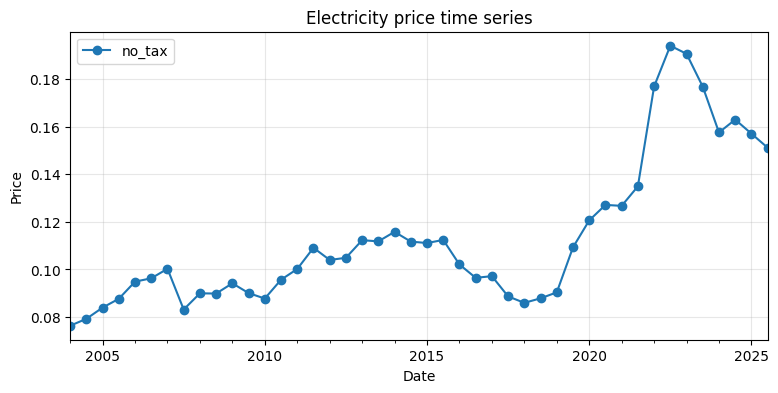

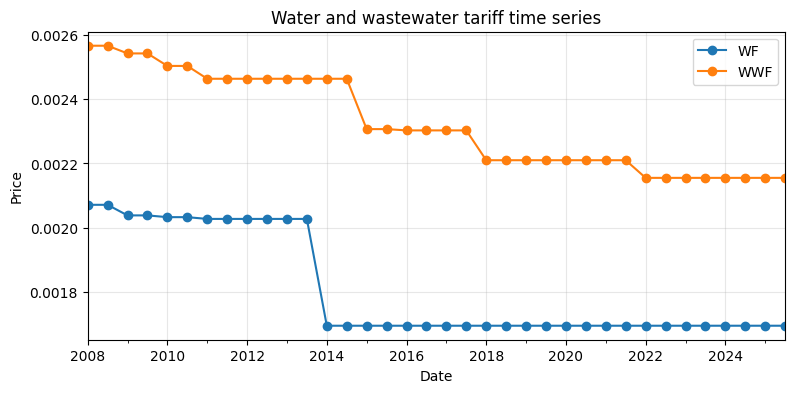

,Input group,Distribution,Range,Mode,Reason
0,Historical metals,triangular,observed min to observed max,historical mean,historical price series available
1,S1/S2 electricity and water resource costs,triangular,current scenario lower to higher value,current scenario mean,derived dynamically from active S1/S2 calculat...
2,Components without time series,uniform,importance-based,none,point estimate only


In [2]:
# ============================================================

# Distribution assumptions and diagnostic helpers

# AWE

# ============================================================

#

# IMPORTANT:

# This cell contains only STATIC uncertainty assumptions and

# helper functions.

#

# Scenario-dependent S1/S2 resource cost, OPEX and TCO

# distributions are NOT hard-coded here.

# They must be generated later from the active S1/S2 model

# calculations after df_global, OPEX and TCO have been calculated.

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Distribution policy

# ------------------------------------------------------------
 
DISTRIBUTION_POLICY = {

    "historical_time_series":

        "triangular: observed minimum, historical mean as mode, observed maximum",
 
    "scenario_resource_cost":

        "triangular: current scenario lower value, current scenario mean as mode, current scenario higher value",
 
    "point_estimate_only":

        "uniform: no empirical mode is available",

}
 
 
# ------------------------------------------------------------

# 2. Uncertainty ranges for components without time series

# ------------------------------------------------------------
 
UNCERTAINTY_RANGE_BY_IMPORTANCE = {

    "high": {

        "min_share": 0.10,

        "relative_half_width": 0.25

    },

    "medium": {

        "min_share": 0.01,

        "relative_half_width": 0.20

    },

    "low": {

        "min_share": 0.00,

        "relative_half_width": 0.10

    },

}
 
 
# ------------------------------------------------------------

# 3. Historical distributions

# ------------------------------------------------------------

#

# Only genuine historical input distributions are stored here.

# S1/S2 resource-cost distributions are deliberately NOT stored

# here because they depend on the active scenario calculation.

# ------------------------------------------------------------
 
HISTORICAL_DISTRIBUTIONS = {
 
    "metals": {
 
        "Steel": {

            "mean": 0.5831,

            "std": 0.1404676025581025,

            "variance": 0.01973114736842105,

            "min": 0.37,

            "max": 0.905,

            "range": 0.535,

            "c": 0.3983177570093457

        },
 
        "Copper": {

            "mean": 7.274755925478757,

            "std": 1.453860395124267,

            "variance": 2.113710048510888,

            "min": 4.867897429653678,

            "max": 9.946881947016749,

            "range": 5.078984517363071,

            "c": 0.4738857713775197

        },
 
        "Titanium": {

            "mean": 11.925,

            "std": 1.018706610312673,

            "variance": 1.037763157894737,

            "min": 10.5,

            "max": 15.0,

            "range": 4.5,

            "c": 0.3166666666666668

        },
 
        "Iridium": {

            "mean": 57171.74430158868,

            "std": 56402.09775194612,

            "variance": 3181196630.820086,

            "min": 11217.17283387429,

            "max": 163003.2337735307,

            "range": 151786.0609396564,

            "c": 0.30275883821758803

        },
 
        "Nickel": {

            "mean": 18.08900217153637,

            "std": 6.413925515723414,

            "variance": 41.13844052124786,

            "min": 9.595179080988459,

            "max": 37.13584189039519,

            "range": 27.54066280940673,

            "c": 0.30841026410035344

        },
 
        "Platinum": {

            "mean": 57171.74430158882,

            "std": 56402.09775194625,

            "variance": 3181196630.820101,

            "min": 11217.17283387431,

            "max": 163003.2337735311,

            "range": 151786.0609396567,

            "c": 0.302758838217588

        },

    }

}
 
 
# ------------------------------------------------------------

# 4. Static model distributions

# ------------------------------------------------------------

#

# These values describe the AWE material-cost uncertainty.

#

# IMPORTANT:

# S1/S2 OPEX and TCO are NOT defined here anymore.

# They will be generated later from the current model outputs.

# ------------------------------------------------------------
 
MODEL_DISTRIBUTIONS = {
 
    "AWE_material_cost": {

        "min": 704990.0967036329,

        "mean": 928695.448652927,

        "max": 1227688.2467915213,

        "range": 522698.15008788847

    }
 
}
 
 
# ------------------------------------------------------------

# 5. Generic helper: build min / mean / max statistics

# ------------------------------------------------------------
 
def make_stats(low, mean, high):

    """

    Create a statistics dictionary used by the Monte Carlo inputs.
 
    'mean' represents the central model value and is used as

    the mode when a triangular distribution is constructed.

    """
 
    low = float(low)

    mean = float(mean)

    high = float(high)
 
    if not (low <= mean <= high):

        raise ValueError(

            f"Invalid uncertainty range: "

            f"low={low}, mean={mean}, high={high}"

        )
 
    return {

        "min": low,

        "mean": mean,

        "max": high,

        "range": high - low

    }
 
 
# ------------------------------------------------------------

# 6. Helper: robust summation of a dataframe column

# ------------------------------------------------------------
 
def numeric_sum(series):

    """

    Convert a pandas Series to numeric values and return its sum.

    Non-numeric or missing entries are treated as zero.

    """
 
    return float(

        pd.to_numeric(series, errors="coerce")

        .fillna(0)

        .sum()

    )
 
 
# ------------------------------------------------------------

# 7. Helper: generate scenario resource-cost statistics

# ------------------------------------------------------------
 
def build_scenario_resource_stats(

    df,

    lower_col,

    mean_col,

    higher_col

):

    """

    Build scenario-specific resource-cost uncertainty directly

    from the active S1/S2 dataframe.
 
    This prevents S1/S2 Monte Carlo inputs from becoming

    disconnected from the deterministic scenario calculations.

    """
 
    return make_stats(

        numeric_sum(df[lower_col]),

        numeric_sum(df[mean_col]),

        numeric_sum(df[higher_col])

    )
 
 
# ------------------------------------------------------------

# 8. Distribution helper functions

# ------------------------------------------------------------
 
def triangular_from_stats(stats):

    """

    scipy.stats.triang expects:

        c     = (mode - lower) / (upper - lower)

        loc   = lower

        scale = upper - lower

    """
 
    lower = float(stats["min"])

    upper = float(stats["max"])

    mode = float(

        stats.get(

            "mean",

            lower + (upper - lower) / 2

        )

    )
 
    if upper <= lower:

        return {

            "c": 0.5,

            "loc": lower,

            "scale": 0.0

        }
 
    c = (mode - lower) / (upper - lower)
 
    return {

        "c": float(max(0.0, min(1.0, c))),

        "loc": lower,

        "scale": upper - lower

    }
 
 
def uniform_from_bounds(lower, upper):

    """

    scipy.stats.uniform expects:

        loc   = lower

        scale = upper - lower

    """
 
    lower = float(lower)

    upper = float(upper)
 
    if upper < lower:

        lower, upper = upper, lower
 
    return {

        "loc": lower,

        "scale": upper - lower

    }
 
 
def uniform_from_stats(stats):

    return uniform_from_bounds(

        stats["min"],

        stats["max"]

    )
 
 
# ------------------------------------------------------------

# 9. Component uncertainty helpers

# ------------------------------------------------------------
 
def classify_cost_share(cost_share):
 
    if cost_share >= UNCERTAINTY_RANGE_BY_IMPORTANCE["high"]["min_share"]:

        return "high"
 
    if cost_share >= UNCERTAINTY_RANGE_BY_IMPORTANCE["medium"]["min_share"]:

        return "medium"
 
    return "low"
 
 
def uniform_around_value(

    value,

    cost_share=None,

    relative_half_width=None

):

    """

    Build a uniform uncertainty range around a point estimate.
 
    If no explicit half-width is provided, the component's

    cost share determines the uncertainty range.

    """
 
    value = float(value)
 
    if relative_half_width is None:
 
        importance = classify_cost_share(

            0.0 if cost_share is None else float(cost_share)

        )
 
        relative_half_width = (

            UNCERTAINTY_RANGE_BY_IMPORTANCE[

                importance

            ]["relative_half_width"]

        )
 
    return uniform_from_bounds(

        max(

            0.0,

            value * (1.0 - relative_half_width)

        ),

        value * (1.0 + relative_half_width)

    )
 
 
def build_material_uncertainty_table(

    material_df,

    historical_materials=None

):

    """

    Create an audit table documenting the uncertainty assumption

    applied to each material/component.

    """
 
    historical_materials = set(

        historical_materials or []

    )
 
    table = material_df.copy()
 
    table = table[

        table["Material and Component"]

        .astype(str)

        .str.lower() != "total"

    ].copy()
 
    table["Price"] = pd.to_numeric(

        table["Price"],

        errors="coerce"

    )
 
    total = table["Price"].sum()
 
    table["Cost share"] = (

        table["Price"] / total

        if total

        else 0.0

    )
 
    table["Importance"] = (

        table["Cost share"]

        .apply(classify_cost_share)

    )
 
    table["Relative half-width"] = (

        table["Importance"]

        .map(

            lambda x:

            UNCERTAINTY_RANGE_BY_IMPORTANCE[

                x

            ]["relative_half_width"]

        )

    )
 
    table["Distribution"] = (

        table["Material and Component"]

        .apply(

            lambda x:

            "triangular"

            if x in historical_materials

            else "uniform"

        )

    )
 
    table["Reason"] = table.apply(

        lambda row:

            "historical price series available"

            if row["Distribution"] == "triangular"

            else (

                f"no time series; "

                f"{row['Importance']} cost impact, "

                f"uniform +/-"

                f"{row['Relative half-width']:.0%}"

            ),

        axis=1

    )
 
    return (

        table

        .sort_values(

            "Price",

            ascending=False

        )

        .reset_index(drop=True)

    )
 
 
# ------------------------------------------------------------

# 10. Diagnostic plot helper

# ------------------------------------------------------------
 
def plot_price_series(

    df,

    date_col="DATE",

    value_cols=None,

    title="Historical price series"

):

    """

    Plot historical price inputs for visual inspection.

    """
 
    value_cols = (

        value_cols

        or [

            c for c in df.columns

            if c != date_col

        ]

    )
 
    ax = df.plot(

        x=date_col,

        y=value_cols,

        marker="o",

        figsize=(9, 4)

    )
 
    ax.set_title(title)

    ax.set_xlabel("Date")

    ax.set_ylabel("Price")

    ax.grid(True, alpha=0.3)
 
    plt.show()
 
    return ax
 
 
# ------------------------------------------------------------

# 11. Diagnostic plots for historical electricity and water

# ------------------------------------------------------------
 
plot_price_series(

    pd.DataFrame(data_elc),

    value_cols=["no_tax"],

    title="Electricity price time series"

)
 
plot_price_series(

    pd.DataFrame(water_data),

    value_cols=["WF", "WWF"],

    title="Water and wastewater tariff time series"

)
 
 
# ------------------------------------------------------------

# 12. Documentation table

# ------------------------------------------------------------
 
distribution_assumptions = pd.DataFrame(

    [

        {

            "Input group": "Historical metals",

            "Distribution": "triangular",

            "Range": "observed min to observed max",

            "Mode": "historical mean",

            "Reason": "historical price series available"

        },
 
        {

            "Input group": "S1/S2 electricity and water resource costs",

            "Distribution": "triangular",

            "Range": "current scenario lower to higher value",

            "Mode": "current scenario mean",

            "Reason": "derived dynamically from active S1/S2 calculations"

        },
 
        {

            "Input group": "Components without time series",

            "Distribution": "uniform",

            "Range": "importance-based",

            "Mode": "none",

            "Reason": "point estimate only"

        },

    ]

)
 
distribution_assumptions


In [3]:
# Number of decimal places for Pandas output
pd.options.display.float_format = '{:20,.3f}'.format


In [4]:
# CAPEX - material cost for 5 MW AWE
# original CAPEX cell retained, but technology changed from PEMWE to AWE with updated AWE prices.

# Feed material data and corresponding price in
# Material type
material = ['Steel', 'Nickel', 'Copper', 'Zirfon Membrane', 'PTFE', 'HDPE', 'Power Cable', 'Data Cable',
            'KOH Tank', 'Gas-separator', 'Heat-exchanger', 'Water pump', 'Rectifier / power electronics',
            'Control unit', 'Housing']
# Set the corresponding amount for material type            
amount = [35511.808, 6721.452, 1855.36, 464, 3164.48, 304, 200, 2000,
          1, 2, 1, 4, 22, 1, 1]
# Set the unit for material type
material_unit = ['kg']*3
material_unit.extend(['m2'])
material_unit.extend(['kg']*2)
material_unit.extend(['m']*2)
material_unit.extend(['pcs']*7)

# Corresponding single price
# updated current AWE prices
price = [HISTORICAL_DISTRIBUTIONS['metals']['Steel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Nickel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Copper']['mean'],
         293.12, 83.1818181818182, 9.47368421052632, 47, 1.19,
         1195.82007741176, 2496.38117647059, 2735, 497, 15000, 13350.4, 4750]

single_price_unit = ['€/kg']*3
single_price_unit.extend(['€/m2'])
single_price_unit.extend(['€/kg']*2)
single_price_unit.extend(['€/m']*2)
single_price_unit.extend(['€/pcs']*7)

price_unit = ['€']*15

# Use pandas to organize the data and provide the names of the categories in the table
df = pd.DataFrame({'Material and Component' : material, 
                   'Amount':  amount,
                   'Unit' : material_unit,
                   'Single Price': price,
                   'Single Price Unit': single_price_unit,
                   'Price Unit': price_unit
                    })

# Calculate price based on amount and single price
df.insert(5, 'Price', [a*b for a, b in zip(df['Amount'], df['Single Price'])])

# calculate total price of every material
df = df.append({'Material and Component': 'Total', 'Price': df['Price'].sum(), 'Price Unit':'€'}, ignore_index=True)

# add name of row in table (Total)
as_list = df.index.tolist()
as_list[-1] = 'Total'
df.index = as_list

df.fillna('', inplace=True)

df.head(22)


# Rank materials and components by their cost contribution.
# This table explains the uncertainty ranges used below for point-estimate-only inputs.
# Historical materials keep triangular distributions; the remaining components use
# uniform ranges selected from their cost share.
material_uncertainty = build_material_uncertainty_table(df, historical_materials=['Steel', 'Nickel', 'Copper'])
material_uncertainty[['Material and Component', 'Price', 'Cost share', 'Importance', 'Distribution', 'Relative half-width', 'Reason']]


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_22364\1546301773.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)



,Material and Component,Price,Cost share,Importance,Distribution,Relative half-width,Reason
0,Rectifier / power electronics,"330,000.000",0.355,high,uniform,0.250,"no time series; high cost impact, uniform +/-25%"
1,PTFE,"263,227.200",0.283,high,uniform,0.250,"no time series; high cost impact, uniform +/-25%"
2,Zirfon Membrane,"136,007.680",0.146,high,uniform,0.250,"no time series; high cost impact, uniform +/-25%"
3,Nickel,"121,584.360",0.131,high,triangular,0.250,historical price series available
4,Steel,"20,706.935",0.022,medium,triangular,0.200,historical price series available
5,Copper,"13,497.291",0.015,medium,triangular,0.200,historical price series available
6,Control unit,"13,350.400",0.014,medium,uniform,0.200,"no time series; medium cost impact, uniform +/..."
7,Power Cable,"9,400.000",0.010,medium,uniform,0.200,"no time series; medium cost impact, uniform +/..."
8,Gas-separator,"4,992.762",0.005,low,uniform,0.100,"no time series; low cost impact, uniform +/-10%"
9,Housing,"4,750.000",0.005,low,uniform,0.100,"no time series; low cost impact, uniform +/-10%"


In [5]:
# CAPEX result (one figure)

# Extract total cost/price from the defined dataframe
material_cost = df['Price'].loc['Total']

# Feed needed data in
kwargs={
        'inflation_rate' : 0.01,                # Inflation rate
        'equity' : 0.25,                        # Equity
        'eq_rate_return' : 0.07,                # Equity rate of return
        'debt' : 0.75,                          # Debt
        'db_intrst_rate' : 0.045,               # Debt interest rate
        'material_full' : material_cost,        # Material cost - comes from the table above
        'per_m' : 0.208                         # Percentage of material cost (for labour cost)
        }

# Sort Labour and Investment cost out 
inv_cost = invest_cost(material=material_cost, ictg=0, **kwargs)        # ictg: Invest tax credit of grant

print(f"Investment Cost {inv_cost:.2f}")
# Build the propagated AWE CAPEX distribution dynamically from the active
# material-cost distribution and the same labour/grant bounds used below.
capex_labour_low = 410000.0
capex_labour_high = 419000.0
capex_labour_mean = (capex_labour_low + capex_labour_high) / 2.0
ictg_low = 0.0
ictg_high = 1000.0
ictg_mean = (ictg_low + ictg_high) / 2.0

MODEL_DISTRIBUTIONS["AWE_CAPEX"] = make_stats(
    MODEL_DISTRIBUTIONS["AWE_material_cost"]["min"] + capex_labour_low - ictg_high,
    MODEL_DISTRIBUTIONS["AWE_material_cost"]["mean"] + capex_labour_mean - ictg_mean,
    MODEL_DISTRIBUTIONS["AWE_material_cost"]["max"] + capex_labour_high - ictg_low,
)

print("Dynamic AWE CAPEX distribution:", MODEL_DISTRIBUTIONS["AWE_CAPEX"])
# Alias used by the scenario-specific TCO Monte Carlo cells.
AWE_CAPEX_STATS = MODEL_DISTRIBUTIONS["AWE_CAPEX"].copy()
print("AWE_CAPEX_STATS:", AWE_CAPEX_STATS)


Construction Labour Cost: 193168.65331980874
Investment Cost 1121864.10
Dynamic AWE CAPEX distribution: {'min': 1113990.0967036327, 'mean': 1342695.4486529268, 'max': 1646688.2467915213, 'range': 532698.1500878886}
AWE_CAPEX_STATS: {'min': 1113990.0967036327, 'mean': 1342695.4486529268, 'max': 1646688.2467915213, 'range': 532698.1500878886}


In [6]:
# ============================================================
# Save AWE component-level CAPEX baseline for stress testing
# ============================================================

awe_component_table = material_uncertainty[
    ['Material and Component', 'Price', 'Cost share']
].copy()

awe_component_costs = (
    awe_component_table
    .set_index('Material and Component')['Price']
    .astype(float)
    .to_dict()
)

awe_material_cost_base = float(material_cost)
awe_capex_base = float(inv_cost)

print("AWE baseline material cost:",
      f"{awe_material_cost_base:,.2f} €")
print("AWE baseline CAPEX:",
      f"{awe_capex_base:,.2f} €")

print("\nComponents used for stress test:")
for component in [
    'Rectifier / power electronics',
    'PTFE',
    'Zirfon Membrane',
    'Nickel'
]:
    print(
        component,
        f"{awe_component_costs[component]:,.2f} €"
    )


AWE baseline material cost: 928,695.45 €
AWE baseline CAPEX: 1,121,864.10 €

Components used for stress test:
Rectifier / power electronics 330,000.00 €
PTFE 263,227.20 €
Zirfon Membrane 136,007.68 €
Nickel 121,584.36 €


Running 'CAPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 667.03outvar/s]
Simulation complete! Runtime: 0:00:00.062977
Calculating sensitivity indices for 'CAPEX'...
Calculating optimal hyperparameters Φ for 'CAPEX' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


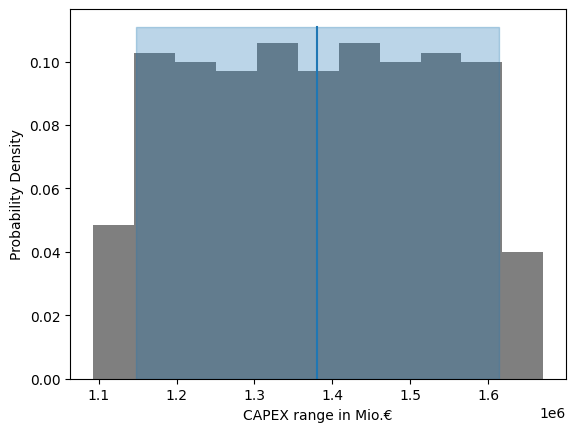

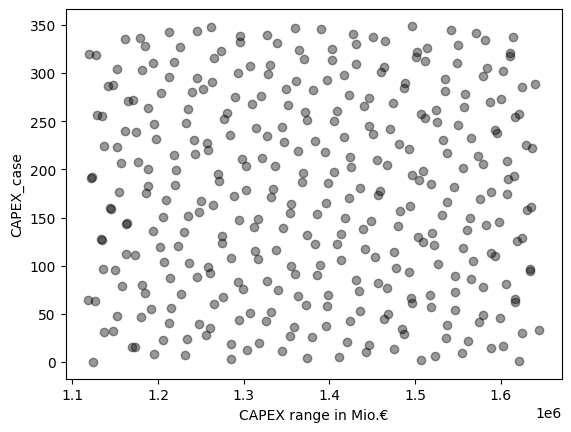

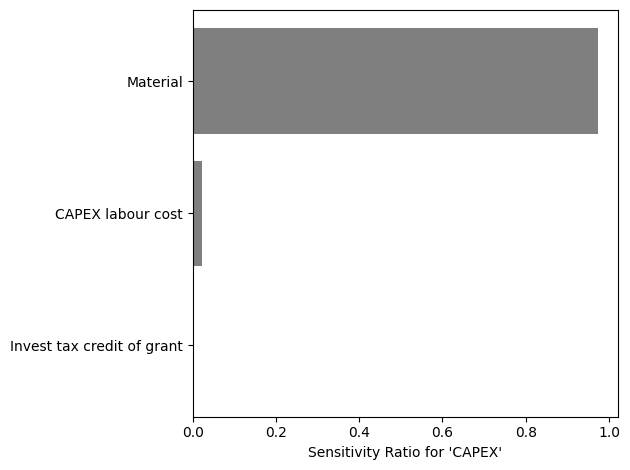

In [7]:
# Monaco CAPEX - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(material, capex_labour, ictg):
    """CAPEX only depends on material, labour and investment tax credit here.

    The original cell also sampled WACC-related variables. However, monte_capex()
    discounts with exponent **0, so those variables have no numerical effect on CAPEX.
    Keeping zero-effect inputs in Monaco's D-VARS sensitivity step can make the
    covariance matrix singular.
    """
    capex = material + capex_labour - ictg
    return (capex, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    material = case.invals['Material'].val
    capex_labour = case.invals['CAPEX labour cost'].val
    ictg = case.invals['Invest tax credit of grant'].val

    return (material, capex_labour, ictg)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, capex):
    case.addOutVal(name='CAPEX', val=capex)
    case.addOutVal(name='CAPEX_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='CAPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# loc: represents the lower limit of the distribution
# scale: the interval length of the distribution
# e.g: using loc=0 and scale=1 we get a standard uniform distribution on [0, 1]
# By manually change loc and scale can manage the uncertainty of the cost
# Only variables that numerically affect CAPEX are included.
# WACC-related variables are excluded here because the CAPEX equation is not discounted at t=0.
sim.addInVar(name='Material', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_material_cost']))  # propagated from AWE material-cost inputs
sim.addInVar(name='CAPEX labour cost', dist=uniform, distkwargs={'loc': capex_labour_low, 'scale': capex_labour_high - capex_labour_low})
sim.addInVar(name='Invest tax credit of grant', dist=uniform, distkwargs=uniform_from_bounds(ictg_low, ictg_high))  # loc is lower bound, scale is range

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['CAPEX'].addVarStat('mean')
sim.outvars['CAPEX'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['CAPEX'])
plt.xlabel('CAPEX range in Mio.€')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['CAPEX'],
sim.outvars['CAPEX_case'])
# add Mio.€ in
plt.xlabel('CAPEX range in Mio.€')

# Calculate the sensitivity of the dice sum to each of the input variables
try:
    sim.calcSensitivities('CAPEX')
    sim.outvars['CAPEX'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for CAPEX was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


Running 'Material Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 15 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 575.75outvar/s] 
Simulation complete! Runtime: 0:00:00.069405
Calculating sensitivity indices for 'Material Cost'...
Calculating optimal hyperparameters Φ for 'Material Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


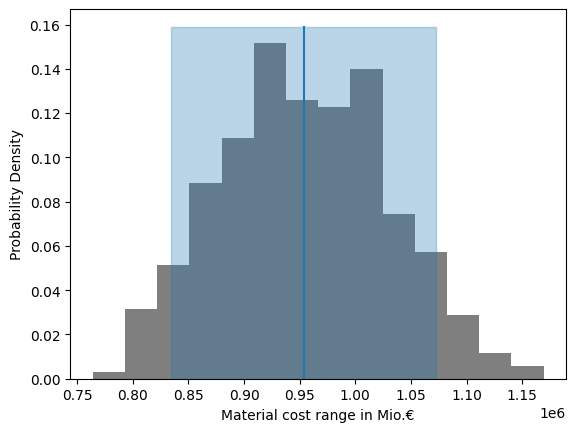

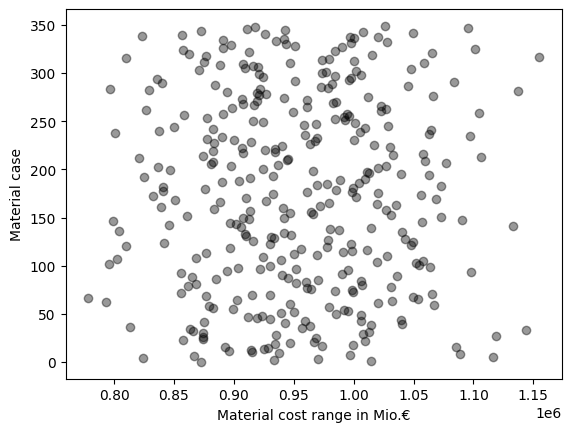

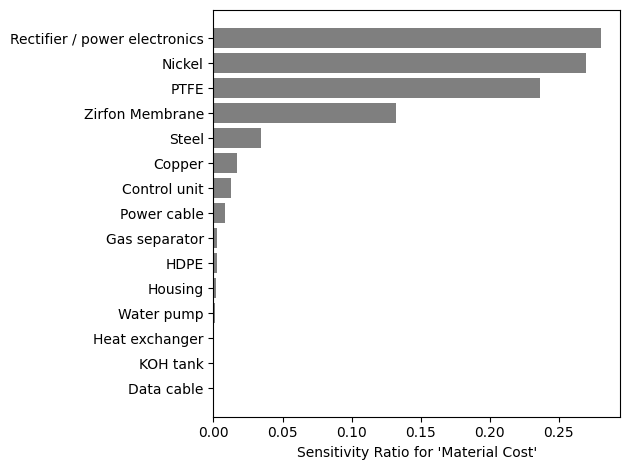

In [8]:
# Monaco material cost - Price range and sensitivity ratio
# original Monaco material-cost section retained; material variables changed from PEMWE to AWE.

# Function for running the monte carlo simulation
def run(steel, nickel, copper, zirfon_membrane, ptfe, hdpe,
        power_cable, data_cable, koh_tank, gas_separator, heat_exchanger,
        water_pump, rectifier_power_electronics, control_unit, housing):

    # run the material cost simulation
    material_cost = monte_awe_capex_5mw_current(steel=steel, nickel=nickel, copper=copper,
                                                zirfon_membrane=zirfon_membrane, ptfe=ptfe, hdpe=hdpe,
                                                power_cable=power_cable, data_cable=data_cable,
                                                koh_tank=koh_tank, gas_separator=gas_separator,
                                                heat_exchanger=heat_exchanger, water_pump=water_pump,
                                                rectifier_power_electronics=rectifier_power_electronics,
                                                control_unit=control_unit, housing=housing)
    return (material_cost, )

# Rename the y-axis in results
def preprocess(case):
    steel = case.invals['Steel'].val
    nickel = case.invals['Nickel'].val
    copper = case.invals['Copper'].val
    zirfon_membrane = case.invals['Zirfon Membrane'].val
    ptfe = case.invals['PTFE'].val
    hdpe = case.invals['HDPE'].val
    power_cable = case.invals['Power cable'].val
    data_cable = case.invals['Data cable'].val
    koh_tank = case.invals['KOH tank'].val
    gas_separator = case.invals['Gas separator'].val
    heat_exchanger = case.invals['Heat exchanger'].val
    water_pump = case.invals['Water pump'].val
    rectifier_power_electronics = case.invals['Rectifier / power electronics'].val
    control_unit = case.invals['Control unit'].val
    housing = case.invals['Housing'].val
    return (steel, nickel, copper, zirfon_membrane, ptfe, hdpe, power_cable, data_cable, koh_tank, gas_separator, heat_exchanger, water_pump, rectifier_power_electronics, control_unit, housing)

def postprocess(case, construction_cost):
    case.addOutVal(name='Material Cost', val=construction_cost)
    case.addOutVal(name='Material case', val=case.ncase)
    return None

fcns = {'run' : run, 'preprocess' : preprocess, 'postprocess': postprocess}
n_invests = 350
seed = 123456
sim = mc.Sim(name='Material Cost', ndraws=n_invests, fcns=fcns, seed=seed, samplemethod='sobol_random', singlethreaded=True, savecasedata=False, verbose=True, debug=True)

# Variables used in the simulation
# Historical metals use triangular distributions. Components without time series use
# importance-based uniform ranges from material_uncertainty.
sim.addInVar(name='Steel', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Steel']))
sim.addInVar(name='Nickel', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Nickel']))
sim.addInVar(name='Copper', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Copper']))
sim.addInVar(name='Zirfon Membrane', dist=uniform, distkwargs=uniform_around_value(293.12, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Zirfon Membrane', 'Cost share'].iloc[0]))
sim.addInVar(name='PTFE', dist=uniform, distkwargs=uniform_around_value(83.1818181818182, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'PTFE', 'Cost share'].iloc[0]))
sim.addInVar(name='HDPE', dist=uniform, distkwargs=uniform_around_value(9.47368421052632, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'HDPE', 'Cost share'].iloc[0]))
sim.addInVar(name='Power cable', dist=uniform, distkwargs=uniform_around_value(47, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Power Cable', 'Cost share'].iloc[0]))
sim.addInVar(name='Data cable', dist=uniform, distkwargs=uniform_around_value(1.19, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Data Cable', 'Cost share'].iloc[0]))
sim.addInVar(name='KOH tank', dist=uniform, distkwargs=uniform_around_value(1195.82007741176, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'KOH Tank', 'Cost share'].iloc[0]))
sim.addInVar(name='Gas separator', dist=uniform, distkwargs=uniform_around_value(2496.38117647059, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Gas-separator', 'Cost share'].iloc[0]))
sim.addInVar(name='Heat exchanger', dist=uniform, distkwargs=uniform_around_value(2735, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Heat-exchanger', 'Cost share'].iloc[0]))
sim.addInVar(name='Water pump', dist=uniform, distkwargs=uniform_around_value(497, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Water pump', 'Cost share'].iloc[0]))
sim.addInVar(name='Rectifier / power electronics', dist=uniform, distkwargs=uniform_around_value(15000, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Rectifier / power electronics', 'Cost share'].iloc[0]))
sim.addInVar(name='Control unit', dist=uniform, distkwargs=uniform_around_value(13350.4, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Control unit', 'Cost share'].iloc[0]))
sim.addInVar(name='Housing', dist=uniform, distkwargs=uniform_around_value(4750, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Housing', 'Cost share'].iloc[0]))

sim.runSim()
sim.outvars['Material Cost'].addVarStat('mean')
sim.outvars['Material Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})
mc.plot(sim.outvars['Material Cost'])
plt.xlabel('Material cost range in Mio.€')
mc.plot(sim.outvars['Material Cost'], sim.outvars['Material case'])
plt.xlabel('Material cost range in Mio.€')
try:
    sim.calcSensitivities('Material Cost')
    sim.outvars['Material Cost'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for Material Cost was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


In [9]:
# Transport cost

# List all the cost indicators
waste_typs = ['Mixed scrap', 'Waste for recycling', 'Gypsum board, gypsum waste']
price = [0.23, 0.23, 0.1]
unit = ['€/kg']*3

df = pd.DataFrame({
                   'Waste type': waste_typs,
                   'Price': price,
                   'Unit': unit
                  })

df.head()


,Waste type,Price,Unit
0,Mixed scrap,0.230,€/kg
1,Waste for recycling,0.230,€/kg
2,"Gypsum board, gypsum waste",0.100,€/kg


In [10]:
# OPEX S1 and S2 - End of Life (EoL) cost - Salvage value (SV)
# original EoL table retained, but material list changed from PEMWE to AWE.

material = ['Steel', 'Nickel', 'Copper', 'Zirfon Membrane', 'PTFE', 'HDPE', 'Power Cable', 'Data Cable',
            'KOH Tank', 'Gas-separator', 'Heat-exchanger', 'Water pump', 'Rectifier / power electronics',
            'Control unit', 'Housing']
amount = [35511.808, 6721.452, 1855.36, 464, 3164.48, 304, 200, 2000,
          1, 2, 1, 4, 22, 1, 1]
unit = ['kg']*3 + ['m2'] + ['kg']*2 + ['m']*2 + ['pcs']*7
price = [HISTORICAL_DISTRIBUTIONS['metals']['Steel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Nickel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Copper']['mean'],
         293.12, 83.1818181818182, 9.47368421052632, 47, 1.19,
         1195.82007741176, 2496.38117647059, 2735, 497, 15000, 13350.4, 4750]
price_unit = ['€']*15
recycle_ratio = [0.28, 0.35, 0.43, 0, 0, 0, 0.008, 0.008, 0.0002, 0.0002, 0.0002, 0.0002, 0.000013, 0.000013, 0.000043]
transport_price = [0.23]*15

# Use pandas to organize the data and provide the names of the categories in the table
df_eol = pd.DataFrame({'Material' : material, 
                   'Amount': amount,
                   'Unit' : unit,
                   'Single Price': price,
                   'Price Unit': price_unit,
                   'Recycle ratio': recycle_ratio,
                   'Transport/disposal cost': transport_price,
                    })

# Calculate total price and salvage value
df_eol.insert(5, 'Price', [a*b for a, b in zip(df_eol['Amount'], df_eol['Single Price'])])
df_eol.insert(8, 'Transport/disposal cost total', [a*b for a, b in zip(df_eol['Amount'], df_eol['Transport/disposal cost'])])
df_eol.insert(9, 'Salvage value', [a*b*c for a, b, c in zip(df_eol['Amount'], df_eol['Single Price'], df_eol['Recycle ratio'])])

df_eol = df_eol.append({'Material':'Total',
                        'Price': df_eol['Price'].sum(),
                        'Transport/disposal cost total': df_eol['Transport/disposal cost total'].sum(),
                        'Salvage value': df_eol['Salvage value'].sum()}, ignore_index=True)
as_list = df_eol.index.tolist()
as_list[-1] = 'Total'
df_eol.index = as_list
df_eol.fillna('', inplace=True)
df_eol.head(22)


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_22364\3679267804.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_eol.fillna('', inplace=True)



,Material,Amount,Unit,Single Price,Price Unit,Price,Recycle ratio,Transport/disposal cost,Transport/disposal cost total,Salvage value
0,Steel,"35,511.808",kg,0.583,€,"20,706.935",0.280,0.230,"8,167.716","5,797.942"
1,Nickel,"6,721.452",kg,18.089,€,"121,584.360",0.350,0.230,"1,545.934","42,554.526"
2,Copper,"1,855.360",kg,7.275,€,"13,497.291",0.430,0.230,426.733,"5,803.835"
3,Zirfon Membrane,464.000,m2,293.120,€,"136,007.680",0.000,0.230,106.720,0.000
4,PTFE,"3,164.480",kg,83.182,€,"263,227.200",0.000,0.230,727.830,0.000
5,HDPE,304.000,kg,9.474,€,"2,880.000",0.000,0.230,69.920,0.000
6,Power Cable,200.000,m,47.000,€,"9,400.000",0.008,0.230,46.000,75.200
7,Data Cable,"2,000.000",m,1.190,€,"2,380.000",0.008,0.230,460.000,19.040
8,KOH Tank,1.000,pcs,"1,195.820",€,"1,195.820",0.000,0.230,0.230,0.239
9,Gas-separator,2.000,pcs,"2,496.381",€,"4,992.762",0.000,0.230,0.460,0.999


In [11]:
# OPEX S1 and S2 - Deconstruction cost

# Feed data in function deconstruction_cost (utils.py)
# percentage of cc = percentage of construction cost (for calculate the deconstruction cost)
decon_cost = deconstruction_cost(construction_cost=material_cost, percentage_of_cc=0.06)
print(f"Deconstruction cost {decon_cost:.2f}")


Deconstruction cost 55721.73


In [12]:
 # OPEX S1 and S2 - EoL cost

# EoL cost is caculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25,                        # Equity
        'eq_rate_return': 0.07,                 # Equity rate of return
        'debt': 0.75,                           # Debt
        'db_intrst_rate': 0.045,                # Debt interest rate
        'construction_cost' : material_cost,    # Material cost - comes from table "CAPEX - material cost"
        'percentage_of_cc' : 0.06               # Percentage of material cost (for labour cost)
        }

transport_cost_disposal = df_eol['Transport/disposal cost total'].loc['Total']
salvage_value = df_eol['Salvage value'].loc['Total']

eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=0.01, **kwargs)
print(f"End of Life {eol_cost:.2f}")


End of Life 5847.94


Running 'End Of Life Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 9 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 498.82outvar/s]
Simulation complete! Runtime: 0:00:00.061225
Calculating sensitivity indices for 'EoL Cost'...
Calculating optimal hyperparameters Φ for 'EoL Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


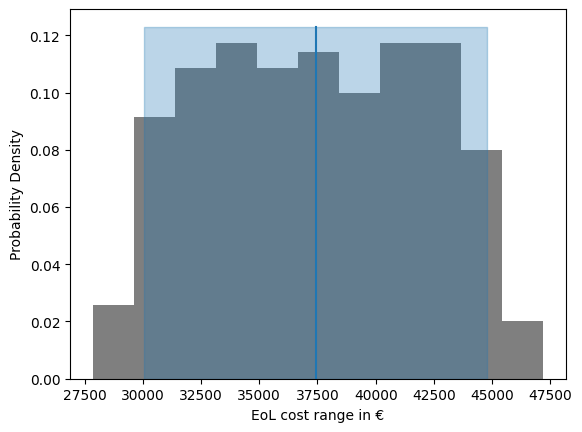

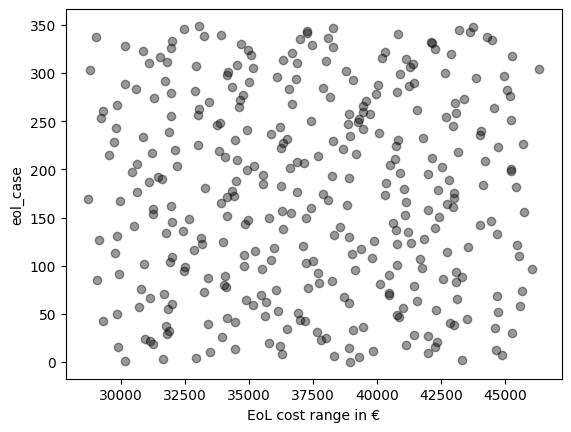

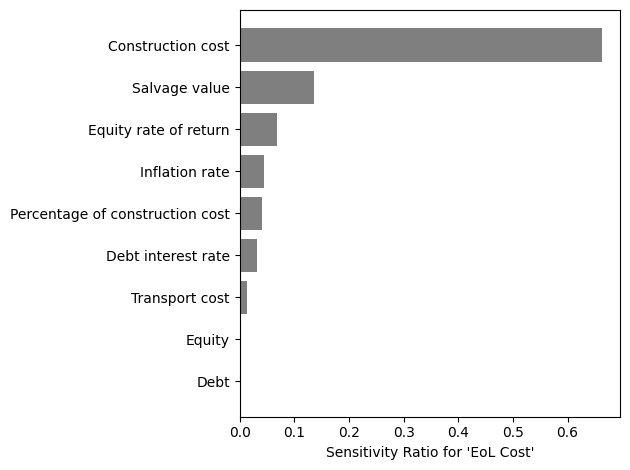

In [13]:
# Monaco EoL cost - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, \
                debt, db_intrst_rate):
    
    # variables used within the end_of_life_cost function (utils.py)
    kwargs={
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        'construction_cost' : construction_cost,      
        'percentage_of_cc' : percentage_of_cc       
        }
    
    # run the capex simulation
    eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=inflation_rate, \
                                **kwargs)
    return (eol_cost, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    transport_cost_disposal = case.invals['Transport cost'].val
    salvage_value = case.invals['Salvage value'].val
    construction_cost = case.invals['Construction cost'].val
    percentage_of_cc = case.invals['Percentage of construction cost'].val
    inflation_rate = case.invals['Inflation rate'].val
    equity = case.invals['Equity'].val
    eq_rate_return = case.invals['Equity rate of return'].val
    debt = case.invals['Debt'].val
    db_intrst_rate = case.invals['Debt interest rate'].val

    return (transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, debt, db_intrst_rate)


# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, eol_cost):
    case.addOutVal(name='EoL Cost', val=eol_cost)
    case.addOutVal(name='eol_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='End Of Life Cost', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Transport cost', dist=uniform, distkwargs={'loc': 7000, 'scale': 500})
sim.addInVar(name='Salvage value', dist=uniform, distkwargs={'loc': 12000, 'scale': 5000})
sim.addInVar(name='Construction cost', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_CAPEX']))  # propagated CAPEX range
sim.addInVar(name='Percentage of construction cost', dist=uniform, distkwargs={'loc': 0.06, 'scale': 0.001})
sim.addInVar(name='Inflation rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.001})
sim.addInVar(name='Equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.01})
sim.addInVar(name='Equity rate of return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='Debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='Debt interest rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.001})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['EoL Cost'].addVarStat('mean')
sim.outvars['EoL Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['EoL Cost'])
plt.xlabel('EoL cost range in €')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['EoL Cost'], 
        sim.outvars['eol_case'])
plt.xlabel('EoL cost range in €')

# Calculate the sensitivity of the dice sum to each of the input variables
try:
    sim.calcSensitivities('EoL Cost')
    sim.outvars['EoL Cost'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for EoL Cost was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


In [14]:
# setup plt plot style
plt.style.use('seaborn-v0_8-ticks')


11:51:12 - cmdstanpy - INFO - Chain [1] start processing
11:51:13 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


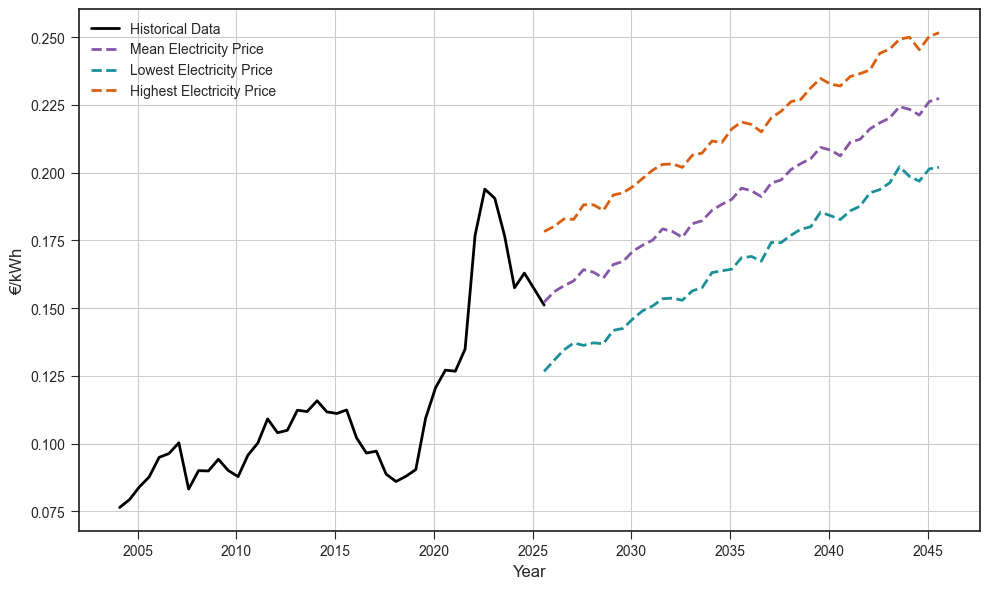

,S1_elc_price_lower,S1_elc_price_upper,S1_elc_price_mean,DATE
0,0.127,0.178,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.183,0.158,2026-07-31
3,0.137,0.183,0.160,2027-01-31
4,0.136,0.188,0.164,2027-07-31
5,0.137,0.188,0.163,2028-01-31
6,0.137,0.186,0.161,2028-07-31
7,0.142,0.192,0.166,2029-01-31
8,0.143,0.193,0.167,2029-07-31
9,0.146,0.195,0.171,2030-01-31


In [15]:
# Prophet - electricity (elc.) cost prediction in scenario 1 (S1)

# Insert historical data for elc. cost
df_elc = pd.DataFrame(data=data_elc)

# Run Prophet for elc. cost prediction (here only incl. "Beschaffung, Netzentgelt, Vertrieb"(BNV) + "Konzessionsabgabe"(KA))
# Use Pandas' iloc function to extract the yhat_lower(2), yhat_upper(3) and yhat(15) (mean) from the prophet result dataframe
prophet_NT_hat = prophet_fit_predict_elc(odf=df_elc, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of elc. cost needed to be considered, then... - 
# EEG-Umlage:                     prophet_EEGU_hat = prophet_fit_predict(odf=df_elc, var="EEGU", years=20, plot=False).iloc[: , [2, 3, 15]]
# KWKG-Umlage:                    prophet_KWKG_hat = prophet_fit_predict(odf=df_elc, var="KWKG", years=20, plot=False).iloc[: , [2, 3, 15]]
# Section 19 StromNEV surcharge:            prophet_NU_hat = prophet_fit_predict(odf=df_elc, var="19U", years=20, plot=False).iloc[: , [2, 3, 15]]
# Offshore-Netzumlage:            prophet_ONU_hat = prophet_fit_predict(odf=df_elc, var="ONU", years=20, plot=False).iloc[: , [2, 3, 15]]
# Umlage für abschaltbare Lasten: prophet_UAL_hat = prophet_fit_predict(odf=df_elc, var="UAL", years=20, plot=False).iloc[: , [2, 3, 15]]
# Electricity tax:                    prophet_SST_hat = prophet_fit_predict(odf=df_elc, var="SST", years=20, plot=False).iloc[: , [2, 3, 15]]


# Results of elc. cost prediction (plot + table)
# Apply an add reduce lambda function to the values of each row in prophet_BNV_hat and prophet_KA_hat
prophet_preds_elc = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
prophet_preds_elc['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_elc.rename(columns = {'yhat':'S1_elc_price_mean', 'yhat_lower':'S1_elc_price_lower',
                                    'yhat_upper':'S1_elc_price_upper'}, inplace = True)

# Sum all ground-truth data and predictions
df_elc['History'] = df_elc.sum(axis=1, numeric_only=True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc['DATE'], df_elc['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc.head(50)


11:51:13 - cmdstanpy - INFO - Chain [1] start processing
11:51:13 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 3 Years...


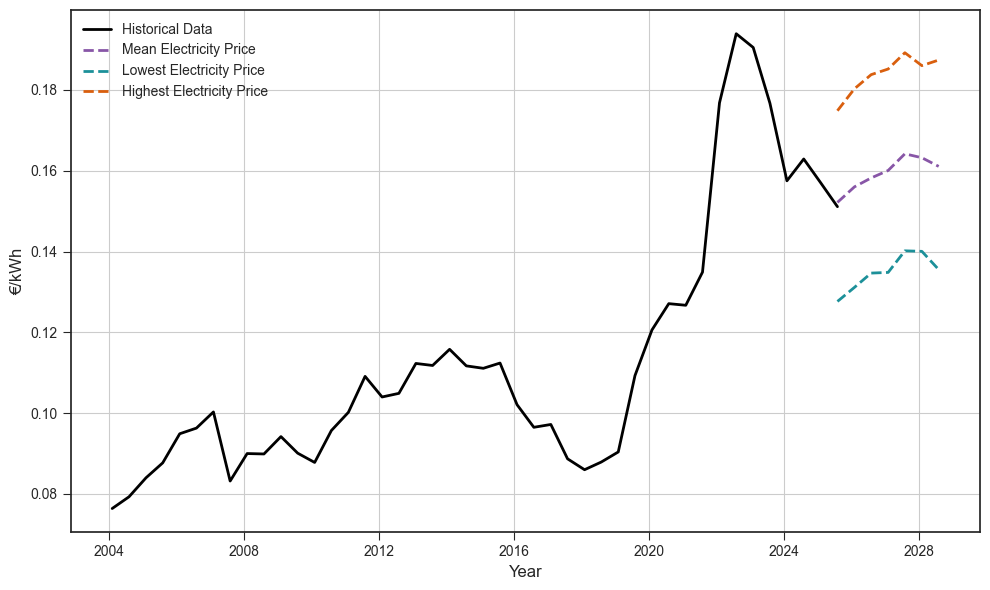

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.128,0.175,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.184,0.158,2026-07-31
3,0.135,0.185,0.160,2027-01-31
4,0.140,0.189,0.164,2027-07-31
5,0.140,0.186,0.163,2028-01-31
6,0.136,0.187,0.161,2028-07-31


In [16]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.1

# For elctricity and water price prediction
df_elc_3y = pd.DataFrame(data=data_elc)

# Electricity cost prediction - 3 years with consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_3_years_after_war(odf=df_elc_3y, var="no_tax", years=3, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - 3 years with consideration of war and epidemic
prophet_preds_elc_3y = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_3y['History'] = df_elc_3y.sum(axis=1, numeric_only=True)
prophet_preds_elc_3y['DATE'] = pd.date_range(start="2025-07-31", end="2028-07-31", freq="6ME")
prophet_preds_elc_3y.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_3y['DATE'], df_elc_3y['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))


# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc_3y.head(50)


11:51:14 - cmdstanpy - INFO - Chain [1] start processing
11:51:14 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


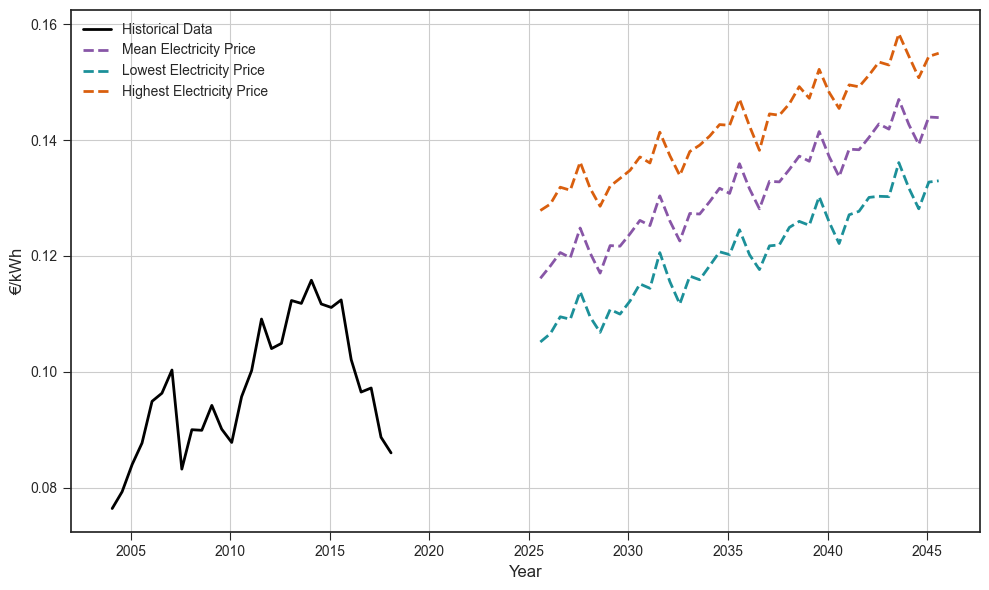

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.105,0.128,0.116,2025-07-31
1,0.107,0.129,0.118,2026-01-31
2,0.109,0.132,0.121,2026-07-31
3,0.109,0.131,0.120,2027-01-31
4,0.114,0.136,0.125,2027-07-31
5,0.109,0.132,0.120,2028-01-31
6,0.107,0.129,0.117,2028-07-31
7,0.111,0.132,0.122,2029-01-31
8,0.110,0.133,0.122,2029-07-31
9,0.112,0.135,0.124,2030-01-31


In [17]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2

df_elc_rest = pd.DataFrame(data=data_nw_elc)

# Electricity cost prediction - without consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_elc_rest(odf=df_elc_rest, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - after 3 years, the impact of war and epedemic will be gone, everything will be back to "normal" (cost trend before 2019)
prophet_preds_elc_nw = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_rest['History'] = df_elc_rest.sum(axis=1, numeric_only=True)
prophet_preds_elc_nw['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_elc_nw.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_rest['DATE'], df_elc_rest['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


#ax = df_elc_rest.plot(kind='line', x='DATE', y='History')
#prophet_preds_elc_nw.plot(ax = ax, x='DATE')

#plt.show()

prophet_preds_elc_nw.head(50)


In [18]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.1
# List of electricity price prediction - without 2023-2026

prophet_elc_rest=prophet_preds_elc_nw.head(50)
prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)
print(prophet_elc_rest)


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_22364\1131735435.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)



     S2_elc_price_lower   S2_elc_price_upper    S2_elc_price_mean       DATE
7                 0.111                0.132                0.122 2029-01-31
8                 0.110                0.133                0.122 2029-07-31
9                 0.112                0.135                0.124 2030-01-31
10                0.115                0.137                0.126 2030-07-31
11                0.114                0.136                0.125 2031-01-31
12                0.121                0.141                0.130 2031-07-31
13                0.116                0.137                0.126 2032-01-31
14                0.112                0.134                0.123 2032-07-31
15                0.117                0.138                0.127 2033-01-31
16                0.116                0.139                0.127 2033-07-31
17                0.118                0.141                0.129 2034-01-31
18                0.121                0.143                0.132 2034-07-31

In [19]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.2
# Combine the 2 prediction together - list it

prophet_elc_price = pd.concat([prophet_preds_elc_3y, prophet_elc_rest], axis=0)
prophet_elc_price.head(50)


,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.128,0.175,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.184,0.158,2026-07-31
3,0.135,0.185,0.160,2027-01-31
4,0.140,0.189,0.164,2027-07-31
5,0.140,0.186,0.163,2028-01-31
6,0.136,0.187,0.161,2028-07-31
7,0.111,0.132,0.122,2029-01-31
8,0.110,0.133,0.122,2029-07-31
9,0.112,0.135,0.124,2030-01-31


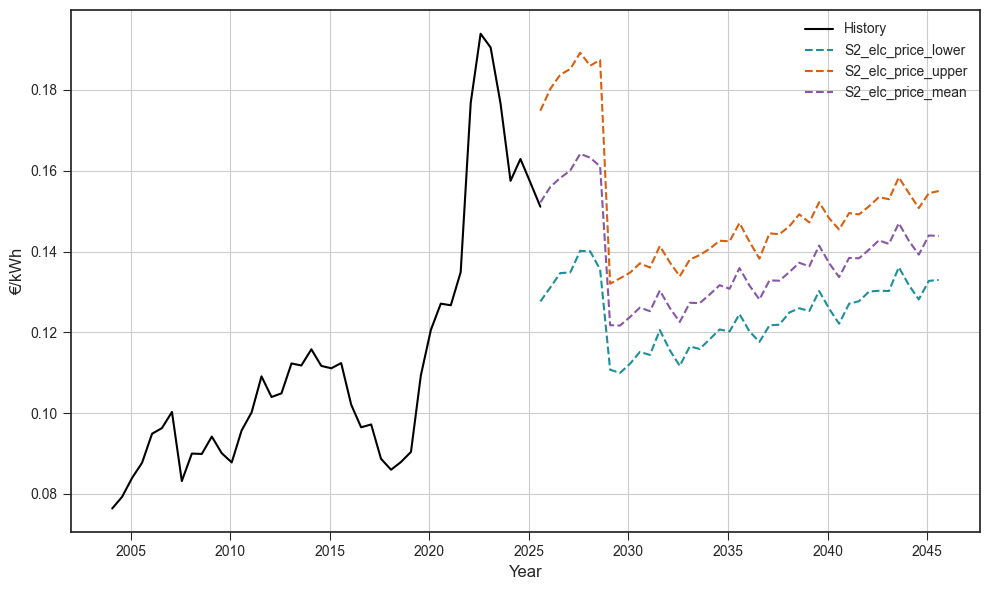

In [20]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 2
# Combine the 2 prediction together, plot the final S2 prediction

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='--', label='S2_elc_price_lower')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='--', label='S2_elc_price_upper')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='--', label='S2_elc_price_mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
# If:
#   title is needed
# Then:
#   ax.set_title('S2', fontsize=14)
ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


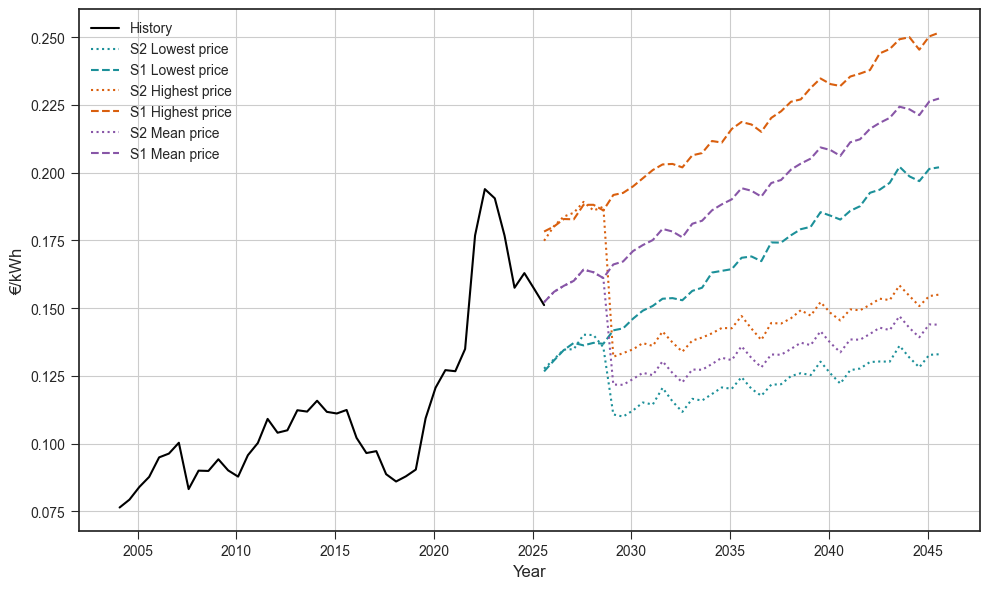

In [21]:
# Prophet - Combine the results of elc. cost in S1 and S2 together - For manuscript

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='dotted', label='S2 Lowest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_lower'].to_list(), color=(28/255, 144/255, 153/255), linestyle='--', label='S1 Lowest price')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='dotted', label='S2 Highest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_upper'].to_list(), color=(217/255, 95/255, 14/255), linestyle='--', label='S1 Highest price')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='dotted', label='S2 Mean price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_mean'].to_list(), color=(136/255, 86/255, 167/255), linestyle='--', label='S1 Mean price')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)

ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


11:51:15 - cmdstanpy - INFO - Chain [1] start processing
11:51:15 - cmdstanpy - INFO - Chain [1] done processing
11:51:15 - cmdstanpy - INFO - Chain [1] start processing


Predicting WF for 20 Years...


11:51:15 - cmdstanpy - INFO - Chain [1] done processing


Predicting WWF for 20 Years...


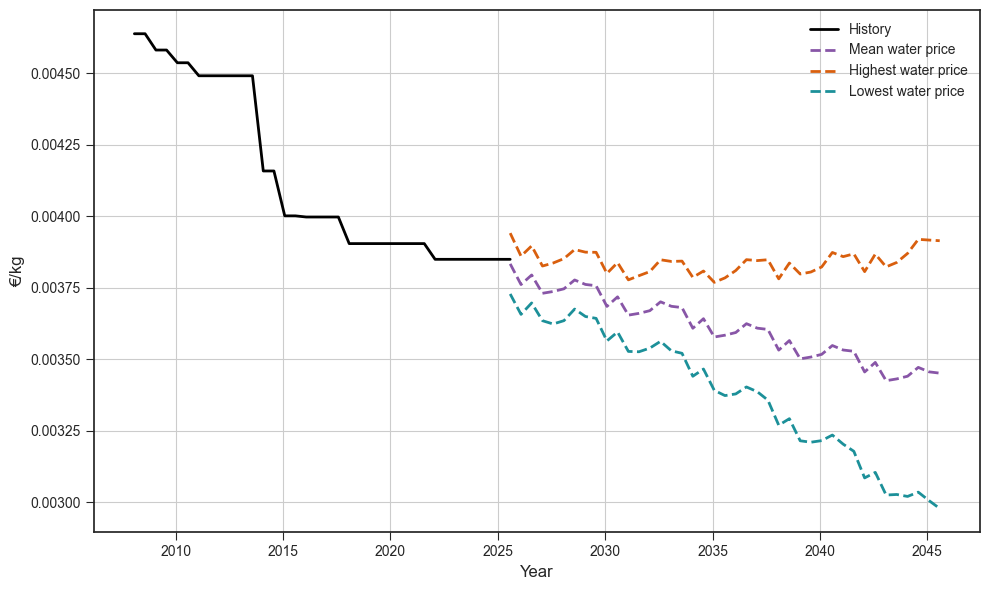

,wat_price_lower,wat_price_upper,wat_price_mean,DATE
0,0.004,0.004,0.004,2025-07-31
1,0.004,0.004,0.004,2026-01-31
2,0.004,0.004,0.004,2026-07-31
3,0.004,0.004,0.004,2027-01-31
4,0.004,0.004,0.004,2027-07-31
5,0.004,0.004,0.004,2028-01-31
6,0.004,0.004,0.004,2028-07-31
7,0.004,0.004,0.004,2029-01-31
8,0.004,0.004,0.004,2029-07-31
9,0.004,0.004,0.004,2030-01-31


In [22]:
# Prophet - water cost prediction

# Insert historical data for water
df = pd.DataFrame(water_data)

# Run package Prophet for water cost prediction (here only incl. "Water fee"(WF) and "Waste water fee"(WWF))
prophet_WF_hat = prophet_fit_predict_water(odf=df, var="WF", years=20, plot=False).iloc[: , [2, 3, 15]]
prophet_WWF_hat = prophet_fit_predict_water(odf=df, var="WWF", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of water needed to be considered... - 
# Value added tax: prophet_VAT_hat = prophet_fit_predict_material(odf=df, var="VAT", years=20, plot=False).iloc[: , [2, 3, 15]]

# Results of water cost prediction (plot + table)
prophet_preds_wat = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_WF_hat,
                                                                 prophet_WWF_hat 
                                                                 ])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df['History'] = df.sum(axis=1, numeric_only=True)

# Sum all ground-truth data and predictions
prophet_preds_wat['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_wat.rename(columns = {'yhat':'wat_price_mean', 'yhat_lower':'wat_price_lower',
                                    'yhat_upper':'wat_price_upper'}, inplace = True)

# Create subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot ground truth data
ax.plot(df['DATE'], df['History'], label='History', linestyle='-', linewidth=2, color='black')

# Plot predictions
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_mean'], label='Mean water price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_upper'], label='Highest water price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_lower'], label='Lowest water price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))

# Add labels for x and y-axis
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kg', fontsize=12)

# Set x-axis ticks every 5 years starting from 2005
ax.xaxis.set_major_locator(mdates.YearLocator(base=5, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#ax.set_title('Water Cost Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_wat.head(50)


In [23]:
# OPEX S1 - resource cost (water, electricity and KOH) for 5 MW AWE
# original OPEX section retained; AWE production, electricity, water and KOH inputs inserted.

h2_produced_amount = [489700]*41
h2_unit_elc = ['kg']*41
elc_used_amount = [52.8]*41
wat_used_amount = [10]*41
koh_used_amount = [0.0001]*41
koh_price = [0.603]*41
elc_price_unit = ['€/kWh']*41
wat_price_unit = ['€/kg']*41
koh_price_unit = ['€/kg']*41

# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                   'Needed KOH': koh_used_amount,
                   'KOH Price': koh_price,
                   'KOH Price Unit': koh_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_preds_elc], axis=1)

# Provide the calculation method within the table
prefix = 'S1'
df_global[f'{prefix} Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global[f'{prefix} Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global[f'{prefix} Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global[f'{prefix} Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_lower'])]
df_global[f'{prefix} Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_upper'])]
df_global[f'{prefix} Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_mean'])]
df_global[f'{prefix} KOH Price'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed KOH'], df_global['KOH Price'])]
df_global[f'{prefix} Total Resources Price Lower'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Lower'], df_global[f'{prefix} Water Price_Lower'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Higher'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Higher'], df_global[f'{prefix} Water Price_Higher'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Mean'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Mean'], df_global[f'{prefix} Water Price_Mean'], df_global[f'{prefix} KOH Price'])]

total_row = {f'{prefix} Electricity Price_Mean': df_global[f'{prefix} Electricity Price_Mean'].sum(),
             f'{prefix} Electricity Price_Higher': df_global[f'{prefix} Electricity Price_Higher'].sum(),
             f'{prefix} Electricity Price_Lower': df_global[f'{prefix} Electricity Price_Lower'].sum(),
             f'{prefix} Water Price_Mean': df_global[f'{prefix} Water Price_Mean'].sum(),
             f'{prefix} Water Price_Higher': df_global[f'{prefix} Water Price_Higher'].sum(),
             f'{prefix} Water Price_Lower': df_global[f'{prefix} Water Price_Lower'].sum(),
             f'{prefix} KOH Price': df_global[f'{prefix} KOH Price'].sum(),
             f'{prefix} Total Resources Price Lower': df_global[f'{prefix} Total Resources Price Lower'].sum(),
             f'{prefix} Total Resources Price Higher': df_global[f'{prefix} Total Resources Price Higher'].sum(),
             f'{prefix} Total Resources Price Mean': df_global[f'{prefix} Total Resources Price Mean'].sum()}
df_global = df_global.append(total_row, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list
df_global.fillna('', inplace=True)

df_global.head()


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_22364\4093462632.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_global.fillna('', inplace=True)



,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,Needed KOH,KOH Price,KOH Price Unit,wat_price_lower,...,S1 Water Price_Lower,S1 Water Price_Higher,S1 Water Price_Mean,S1 Electricity Price_Lower,S1 Electricity Price_Higher,S1 Electricity Price_Mean,S1 KOH Price,S1 Total Resources Price Lower,S1 Total Resources Price Higher,S1 Total Resources Price Mean
0,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,255.101","19,297.143","18,770.567","3,274,055.947","4,608,788.259","3,934,307.136",29.529,"3,292,340.577","4,628,114.930","3,953,107.233"
1,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,905.801","18,903.402","18,416.496","3,379,495.903","4,657,203.796","4,033,665.634",29.529,"3,397,431.233","4,676,136.727","4,052,111.658"
2,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,101.139","19,078.930","18,580.050","3,478,275.107","4,728,172.629","4,090,729.959",29.529,"3,496,405.774","4,747,281.088","4,109,339.539"
3,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,797.630","18,733.733","18,266.740","3,545,911.646","4,725,304.760","4,138,526.652",29.529,"3,563,738.805","4,744,068.022","4,156,822.920"
4,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,740.871","18,785.079","18,297.474","3,522,433.202","4,864,028.521","4,245,138.344",29.529,"3,540,203.602","4,882,843.129","4,263,465.347"


In [24]:
# OPEX S1 (with EoL cost) - Details
# S1_mean

# OPEX S1 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_mean = df_global['S1 Total Resources Price Mean'].tolist()

op_cost_S1_mean = operation_cost(resource_cost=S1_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_mean:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 79989891.46


In [25]:
# OPEX S1 (with EoL cost) - Details
# S1_higher

# OPEX S1 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_high = df_global['S1 Total Resources Price Higher'].tolist()

op_cost_S1_high = operation_cost(resource_cost=S1_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_high:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 90401884.64


In [26]:
# OPEX S1 (with EoL cost) - Details
# S1_lower

# OPEX S1 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_low = df_global['S1 Total Resources Price Lower'].tolist()

op_cost_S1_low = operation_cost(resource_cost=S1_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_low:.2f}")
# Generate S1 uncertainty inputs dynamically from the active scenario model.
AWE_S1_RESOURCE_STATS = build_scenario_resource_stats(
    df_global,
    lower_col="S1 Total Resources Price Lower",
    mean_col="S1 Total Resources Price Mean",
    higher_col="S1 Total Resources Price Higher",
)

MODEL_DISTRIBUTIONS["AWE_S1_OPEX"] = make_stats(
    op_cost_S1_low,
    op_cost_S1_mean,
    op_cost_S1_high,
)

print("Dynamic AWE S1 resource distribution:", AWE_S1_RESOURCE_STATS)
print("Dynamic AWE S1 OPEX distribution:", MODEL_DISTRIBUTIONS["AWE_S1_OPEX"])


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 69675173.71
Dynamic AWE S1 resource distribution: {'min': 354696351.9166446, 'mean': 406619526.6736973, 'max': 459124222.2146507, 'range': 104427870.29800612}
Dynamic AWE S1 OPEX distribution: {'min': 69675173.71048422, 'mean': 79989891.45724763, 'max': 90401884.63610004, 'range': 20726710.925615817}


Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...


AWE S1 resource-cost distribution used for Monte Carlo:
{'min': 354696351.9166446, 'mean': 406619526.6736973, 'max': 459124222.2146507, 'range': 104427870.29800612}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 663.24outvar/s]
Simulation complete! Runtime: 0:00:00.040526
Calculating sensitivity indices for 'OPEX_S1'...
Calculating optimal hyperparameters Φ for 'OPEX_S1' covariances...



AWE OPEX S1 Monte Carlo check
--------------------------------
N      : 350
P5     : 371869140.1219734
Median : 406885623.3681978
Mean   : 406886025.3120541
P95    : 441779692.49517083


Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


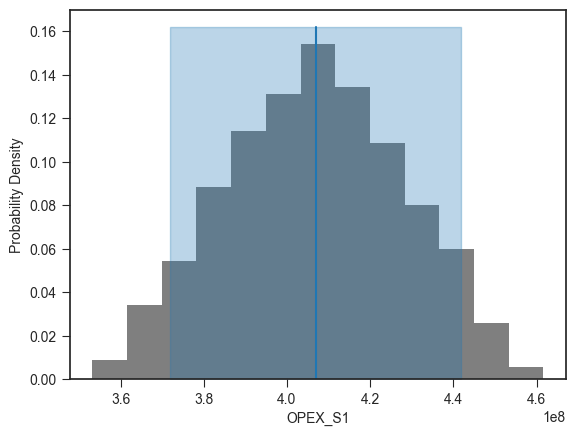

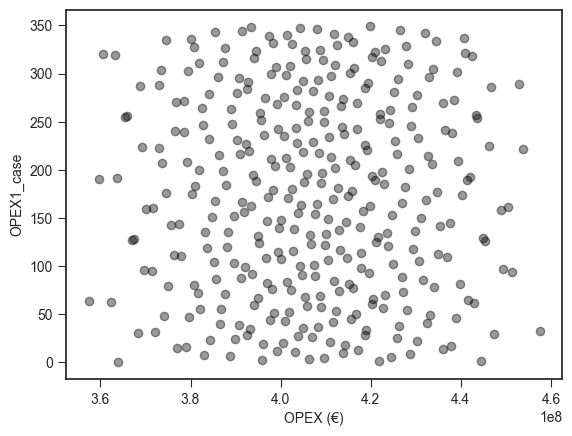

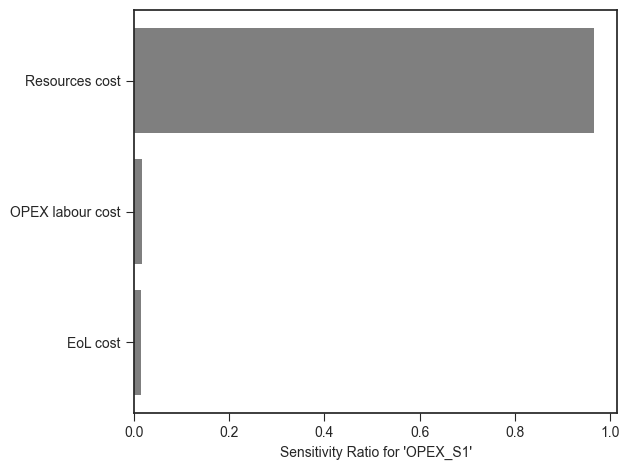

In [27]:
# ============================================================

# Monaco OPEX S1 - Price range and sensitivity ratio

# ============================================================

#

# IMPORTANT:

# The resource-cost uncertainty is generated directly from the

# CURRENT S1 scenario calculation in df_global.

#

# It is no longer taken from a hard-coded historical

# S1 resource-cost distribution.

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S1 resource-cost distribution

# ------------------------------------------------------------
 
AWE_S1_RESOURCE_STATS = build_scenario_resource_stats(

    df=df_global,

    lower_col='S1 Total Resources Price Lower',

    mean_col='S1 Total Resources Price Mean',

    higher_col='S1 Total Resources Price Higher'

)
 
print("AWE S1 resource-cost distribution used for Monte Carlo:")

print(AWE_S1_RESOURCE_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(op_cost, op_labour, eol_cost):
 
    # Calculate total OPEX

    opr_cost = monte_opex(

        op_cost=op_cost,

        op_labour=op_labour,

        eol_cost=eol_cost

    )
 
    return (opr_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess Monte Carlo inputs

# ------------------------------------------------------------
 
def preprocess(case):
 
    op_cost = case.invals['Resources cost'].val

    op_labour = case.invals['OPEX labour cost'].val

    eol_cost = case.invals['EoL cost'].val
 
    return (

        op_cost,

        op_labour,

        eol_cost

    )
 
 
# ------------------------------------------------------------

# 4. Store Monte Carlo outputs

# ------------------------------------------------------------
 
def postprocess(case, opr_cost):
 
    case.addOutVal(

        name='OPEX_S1',

        val=opr_cost

    )
 
    case.addOutVal(

        name='OPEX1_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions used by Monaco

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350
 
# Fixed seed for reproducibility

seed = 123456
 
 
sim = mc.Sim(

    name='OPEX',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol_random',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Monte Carlo input distributions

# ------------------------------------------------------------
 
# CURRENT S1 resource-cost uncertainty

#

# Lower = current S1 lower scenario result

# Mode  = current S1 mean scenario result

# Upper = current S1 higher scenario result
 
sim.addInVar(

    name='Resources cost',

    dist=triang,

    distkwargs=triangular_from_stats(

        AWE_S1_RESOURCE_STATS

    )

)
 
 
# Labour uncertainty

# Existing assumption retained
 
sim.addInVar(

    name='OPEX labour cost',

    dist=uniform,

    distkwargs={

        'loc': 45000,

        'scale': 10000

    }

)
 
 
# End-of-life uncertainty

# Existing assumption retained
 
sim.addInVar(

    name='EoL cost',

    dist=uniform,

    distkwargs={

        'loc': 50000,

        'scale': 2000

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Summary statistics

# ------------------------------------------------------------
 
sim.outvars['OPEX_S1'].addVarStat(

    'mean'

)
 
sim.outvars['OPEX_S1'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S1 samples for later checks

# ------------------------------------------------------------
 
awe_opex_s1_samples = np.asarray(

    sim.outvars['OPEX_S1'].nums,

    dtype=float

).ravel()
 
awe_opex_s1_samples = awe_opex_s1_samples[

    np.isfinite(awe_opex_s1_samples)

]
 
 
print("\nAWE OPEX S1 Monte Carlo check")

print("--------------------------------")

print("N      :", len(awe_opex_s1_samples))

print("P5     :", np.percentile(awe_opex_s1_samples, 5))

print("Median :", np.median(awe_opex_s1_samples))

print("Mean   :", np.mean(awe_opex_s1_samples))

print("P95    :", np.percentile(awe_opex_s1_samples, 95))
 
 
# ------------------------------------------------------------

# 11. Plots

# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['OPEX_S1']

)
 
mc.plot(

    sim.outvars['OPEX_S1'],

    sim.outvars['OPEX1_case']

)
 
plt.xlabel('OPEX (€)')
 
 
# ------------------------------------------------------------

# 12. Existing local sensitivity output

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('OPEX_S1')
    sim.outvars['OPEX_S1'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for OPEX_S1 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


In [28]:
# OPEX S2 - resource cost (water, electricity and KOH) for 5 MW AWE
# original OPEX section retained; AWE production, electricity, water and KOH inputs inserted.

h2_produced_amount = [489700]*41
h2_unit_elc = ['kg']*41
elc_used_amount = [52.8]*41
wat_used_amount = [10]*41
koh_used_amount = [0.0001]*41
koh_price = [0.603]*41
elc_price_unit = ['€/kWh']*41
wat_price_unit = ['€/kg']*41
koh_price_unit = ['€/kg']*41

# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                   'Needed KOH': koh_used_amount,
                   'KOH Price': koh_price,
                   'KOH Price Unit': koh_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_elc_price], axis=1)

# Provide the calculation method within the table
prefix = 'S2'
df_global[f'{prefix} Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global[f'{prefix} Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global[f'{prefix} Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global[f'{prefix} Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_lower'])]
df_global[f'{prefix} Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_upper'])]
df_global[f'{prefix} Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_mean'])]
df_global[f'{prefix} KOH Price'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed KOH'], df_global['KOH Price'])]
df_global[f'{prefix} Total Resources Price Lower'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Lower'], df_global[f'{prefix} Water Price_Lower'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Higher'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Higher'], df_global[f'{prefix} Water Price_Higher'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Mean'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Mean'], df_global[f'{prefix} Water Price_Mean'], df_global[f'{prefix} KOH Price'])]

total_row = {f'{prefix} Electricity Price_Mean': df_global[f'{prefix} Electricity Price_Mean'].sum(),
             f'{prefix} Electricity Price_Higher': df_global[f'{prefix} Electricity Price_Higher'].sum(),
             f'{prefix} Electricity Price_Lower': df_global[f'{prefix} Electricity Price_Lower'].sum(),
             f'{prefix} Water Price_Mean': df_global[f'{prefix} Water Price_Mean'].sum(),
             f'{prefix} Water Price_Higher': df_global[f'{prefix} Water Price_Higher'].sum(),
             f'{prefix} Water Price_Lower': df_global[f'{prefix} Water Price_Lower'].sum(),
             f'{prefix} KOH Price': df_global[f'{prefix} KOH Price'].sum(),
             f'{prefix} Total Resources Price Lower': df_global[f'{prefix} Total Resources Price Lower'].sum(),
             f'{prefix} Total Resources Price Higher': df_global[f'{prefix} Total Resources Price Higher'].sum(),
             f'{prefix} Total Resources Price Mean': df_global[f'{prefix} Total Resources Price Mean'].sum()}
df_global = df_global.append(total_row, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list
df_global.fillna('', inplace=True)

df_global.head()


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_22364\4197644471.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_global.fillna('', inplace=True)



,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,Needed KOH,KOH Price,KOH Price Unit,wat_price_lower,...,S2 Water Price_Lower,S2 Water Price_Higher,S2 Water Price_Mean,S2 Electricity Price_Lower,S2 Electricity Price_Higher,S2 Electricity Price_Mean,S2 KOH Price,S2 Total Resources Price Lower,S2 Total Resources Price Higher,S2 Total Resources Price Mean
0,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,255.101","19,297.143","18,770.567","3,300,464.640","4,520,937.899","3,934,307.136",29.529,"3,318,749.270","4,540,264.571","3,953,107.233"
1,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,905.801","18,903.402","18,416.496","3,390,375.839","4,661,245.224","4,033,665.634",29.529,"3,408,311.169","4,680,178.154","4,052,111.658"
2,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,101.139","19,078.930","18,580.050","3,481,902.644","4,751,695.744","4,090,729.959",29.529,"3,500,033.312","4,770,804.203","4,109,339.539"
3,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,797.630","18,733.733","18,266.740","3,486,176.284","4,787,734.417","4,138,526.652",29.529,"3,504,003.442","4,806,497.679","4,156,822.920"
4,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,740.871","18,785.079","18,297.474","3,624,260.392","4,891,869.148","4,245,138.344",29.529,"3,642,030.792","4,910,683.756","4,263,465.347"


In [29]:
# OPEX S2 (with EoL cost) - Details
# S2_mean

# OPEX S2 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_mean = df_global['S2 Total Resources Price Mean'].tolist()

op_cost_S2_mean = operation_cost(resource_cost=S2_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_mean:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 58379489.98


In [30]:
# OPEX S2 (with EoL cost) - Details
# S2_higher

# OPEX S2 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_high = df_global['S2 Total Resources Price Higher'].tolist()

op_cost_S2_high = operation_cost(resource_cost=S2_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_high:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 64128241.13


In [31]:
# OPEX S2 (with EoL cost) - Details
# S2_lower

# OPEX S2 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_low = df_global['S2 Total Resources Price Lower'].tolist()

op_cost_S2_low = operation_cost(resource_cost=S2_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_low:.2f}")
# Generate S2 uncertainty inputs dynamically from the active scenario model.
AWE_S2_RESOURCE_STATS = build_scenario_resource_stats(
    df_global,
    lower_col="S2 Total Resources Price Lower",
    mean_col="S2 Total Resources Price Mean",
    higher_col="S2 Total Resources Price Higher",
)

MODEL_DISTRIBUTIONS["AWE_S2_OPEX"] = make_stats(
    op_cost_S2_low,
    op_cost_S2_mean,
    op_cost_S2_high,
)

print("Dynamic AWE S2 resource distribution:", AWE_S2_RESOURCE_STATS)
print("Dynamic AWE S2 OPEX distribution:", MODEL_DISTRIBUTIONS["AWE_S2_OPEX"])


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 52701039.47
Dynamic AWE S2 resource distribution: {'min': 265780674.0284234, 'mean': 294115042.4813601, 'max': 322667116.53998953, 'range': 56886442.51156613}
Dynamic AWE S2 OPEX distribution: {'min': 52701039.47084686, 'mean': 58379489.9759603, 'max': 64128241.13322316, 'range': 11427201.6623763}


Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...


AWE S2 resource-cost distribution used for Monte Carlo:
{'min': 265780674.0284234, 'mean': 294115042.4813601, 'max': 322667116.53998953, 'range': 56886442.51156613}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 653.11outvar/s]
Simulation complete! Runtime: 0:00:00.045597
Calculating sensitivity indices for 'OPEX_S2'...
Calculating optimal hyperparameters Φ for 'OPEX_S2' covariances...



AWE OPEX S2 Monte Carlo check
--------------------------------
N      : 350
P5     : 275188626.8538423
Median : 294281466.2157948
Mean   : 294273236.8477801
P95    : 313274720.0163017

AWE S1 vs S2 OPEX Monte Carlo
--------------------------------
S1 median: 406885623.3681978
S2 median: 294281466.2157948
S1 - S2: 112604157.152403


Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


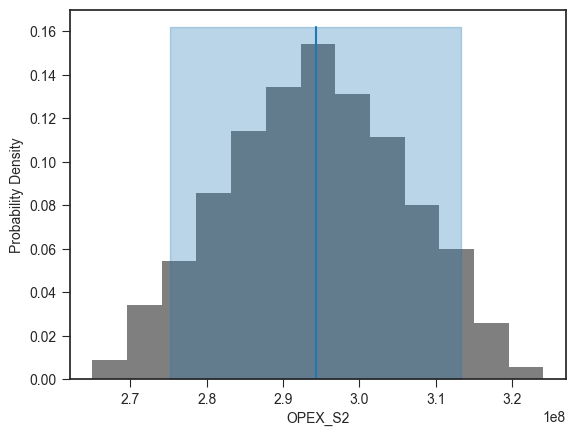

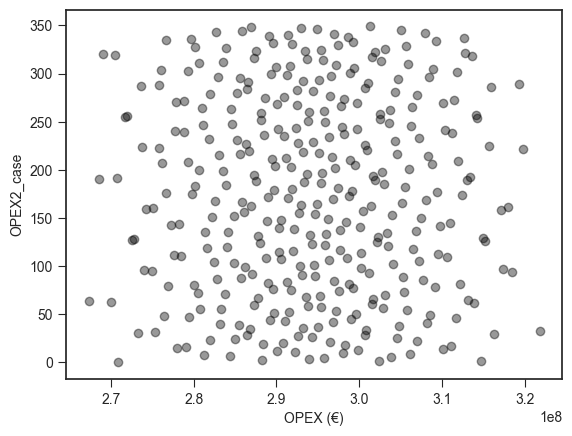

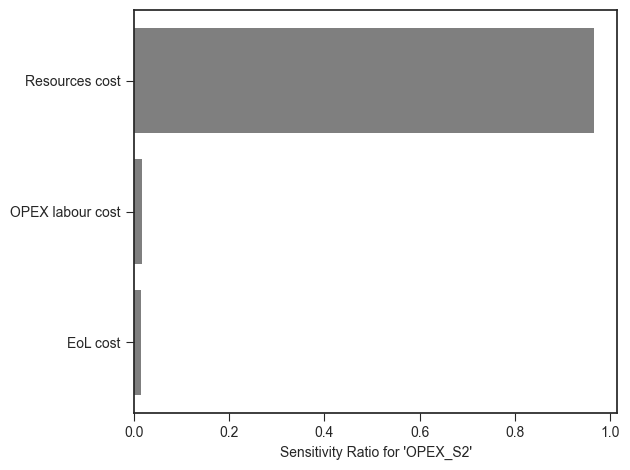

In [32]:
# ============================================================

# Monaco OPEX S2 - Reference electricity-price scenario

# ============================================================

#

# IMPORTANT:

# The resource-cost uncertainty is generated directly from the

# CURRENT S2 scenario calculation in df_global.

#

# It is no longer taken from a hard-coded historical

# S2 resource-cost distribution.

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S2 resource-cost distribution

# ------------------------------------------------------------
 
AWE_S2_RESOURCE_STATS = build_scenario_resource_stats(

    df=df_global,

    lower_col='S2 Total Resources Price Lower',

    mean_col='S2 Total Resources Price Mean',

    higher_col='S2 Total Resources Price Higher'

)
 
print("AWE S2 resource-cost distribution used for Monte Carlo:")

print(AWE_S2_RESOURCE_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(op_cost, op_labour, eol_cost):
 
    # Calculate total OPEX

    opr_cost = monte_opex(

        op_cost=op_cost,

        op_labour=op_labour,

        eol_cost=eol_cost

    )
 
    return (opr_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess Monte Carlo inputs

# ------------------------------------------------------------
 
def preprocess(case):
 
    op_cost = case.invals['Resources cost'].val

    op_labour = case.invals['OPEX labour cost'].val

    eol_cost = case.invals['EoL cost'].val
 
    return (

        op_cost,

        op_labour,

        eol_cost

    )
 
 
# ------------------------------------------------------------

# 4. Store Monte Carlo outputs

# ------------------------------------------------------------
 
def postprocess(case, opr_cost):
 
    case.addOutVal(

        name='OPEX_S2',

        val=opr_cost

    )
 
    case.addOutVal(

        name='OPEX2_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions used by Monaco

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350
 
# IMPORTANT:

# Same seed as S1 so that the scenario comparison is not

# driven by different random sequences.
 
seed = 123456
 
 
sim = mc.Sim(

    name='OPEX',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol_random',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Monte Carlo input distributions

# ------------------------------------------------------------
 
# CURRENT S2 resource-cost uncertainty
 
sim.addInVar(

    name='Resources cost',

    dist=triang,

    distkwargs=triangular_from_stats(

        AWE_S2_RESOURCE_STATS

    )

)
 
 
# Same labour uncertainty as S1
 
sim.addInVar(

    name='OPEX labour cost',

    dist=uniform,

    distkwargs={

        'loc': 45000,

        'scale': 10000

    }

)
 
 
# Same EoL uncertainty as S1
 
sim.addInVar(

    name='EoL cost',

    dist=uniform,

    distkwargs={

        'loc': 50000,

        'scale': 2000

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Summary statistics

# ------------------------------------------------------------
 
sim.outvars['OPEX_S2'].addVarStat(

    'mean'

)
 
sim.outvars['OPEX_S2'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S2 samples

# ------------------------------------------------------------
 
awe_opex_s2_samples = np.asarray(

    sim.outvars['OPEX_S2'].nums,

    dtype=float

).ravel()
 
awe_opex_s2_samples = awe_opex_s2_samples[

    np.isfinite(awe_opex_s2_samples)

]
 
 
print("\nAWE OPEX S2 Monte Carlo check")

print("--------------------------------")

print("N      :", len(awe_opex_s2_samples))

print("P5     :", np.percentile(awe_opex_s2_samples, 5))

print("Median :", np.median(awe_opex_s2_samples))

print("Mean   :", np.mean(awe_opex_s2_samples))

print("P95    :", np.percentile(awe_opex_s2_samples, 95))
 
 
# ------------------------------------------------------------

# 11. Direct S1 versus S2 sanity check

# ------------------------------------------------------------
 
print("\nAWE S1 vs S2 OPEX Monte Carlo")

print("--------------------------------")

print(

    "S1 median:",

    np.median(awe_opex_s1_samples)

)
 
print(

    "S2 median:",

    np.median(awe_opex_s2_samples)

)
 
print(

    "S1 - S2:",

    np.median(awe_opex_s1_samples)

    - np.median(awe_opex_s2_samples)

)
 
 
assert (

    np.median(awe_opex_s1_samples)
>

    np.median(awe_opex_s2_samples)

), (

    "ERROR: AWE S1 Monte Carlo OPEX should be "

    "higher than AWE S2 Monte Carlo OPEX."

)
 
 
# ------------------------------------------------------------

# 12. Plots

# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['OPEX_S2']

)
 
mc.plot(

    sim.outvars['OPEX_S2'],

    sim.outvars['OPEX2_case']

)
 
plt.xlabel('OPEX (€)')
 
 
# ------------------------------------------------------------

# 13. Existing local sensitivity output

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('OPEX_S2')
    sim.outvars['OPEX_S2'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for OPEX_S2 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


In [33]:
# If:
#    resource cost is incl. taxes;
#    depreciation cost is considered;
#    there is any recoverable taxes was taking into account.
# Then: 
#    Tax impacts

# ---- Tax Impacts ----

# Feed needed data in
#kwargs={
#        'equity' : 0.25, 
#        'eq_rate_return': 0.07,
#        'debt': 0.75, 
#        'db_intrst_rate': 0.045,
#        'inflation_rate' : 0.01,
#        }

# Extract resource_cost from OPEX
#resource_cost = df_global['Total Resources Price'].tolist()

#print(resource_cost)

#tax_impct = tax_impact(resource_cost=0, tax_rate=0.3, int_on_debt=0.045, depreciation=0, **kwargs)
#print(f"Tax Impact: {tax_impct:.2f}")


In [34]:
# Life Cycle Cost S1 - Total cost of ownership (TCO)
# with OPEX_S1_mean

# TCO S1 (Mean) is calculated here based on all the parameters listed below
lcc_S1_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_mean:.2f}")


Life Cycle Cost: 81111755.56


In [35]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_higher

# TCO S1 (High) is calculated here based on all the parameters listed below
lcc_S1_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_high:.2f}")


Life Cycle Cost: 91523748.74


In [36]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_lower

# TCO S1 (Low) is calculated here based on all the parameters listed below
lcc_S1_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_low:.2f}")
# Generate S1 TCO uncertainty dynamically from the active deterministic S1 results.
MODEL_DISTRIBUTIONS["AWE_S1_TCO"] = make_stats(
    lcc_S1_low,
    lcc_S1_mean,
    lcc_S1_high,
)
print("Dynamic AWE S1 TCO distribution:", MODEL_DISTRIBUTIONS["AWE_S1_TCO"])


Life Cycle Cost: 70797037.81
Dynamic AWE S1 TCO distribution: {'min': 70797037.81245695, 'mean': 81111755.55922036, 'max': 91523748.73807277, 'range': 20726710.925615817}


In [37]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_mean

# TCO S2 (Mean) is calculated here based on all the parameters listed below
lcc_S2_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_mean:.2f}")


Life Cycle Cost: 59501354.08


In [38]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_higher

# TCO S2 (High) is calculated here based on all the parameters listed below
lcc_S2_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_high:.2f}")


Life Cycle Cost: 65250105.24


In [39]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_lower

# TCO S2 (Low) is calculated here based on all the parameters listed below
lcc_S2_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_low:.2f}")
# Generate S2 TCO uncertainty dynamically from the active deterministic S2 results.
MODEL_DISTRIBUTIONS["AWE_S2_TCO"] = make_stats(
    lcc_S2_low,
    lcc_S2_mean,
    lcc_S2_high,
)
print("Dynamic AWE S2 TCO distribution:", MODEL_DISTRIBUTIONS["AWE_S2_TCO"])


Life Cycle Cost: 53822903.57
Dynamic AWE S2 TCO distribution: {'min': 53822903.5728196, 'mean': 59501354.077933036, 'max': 65250105.2351959, 'range': 11427201.6623763}


Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...


AWE S1 OPEX distribution used for TCO Monte Carlo:
{'min': 69675173.71048422, 'mean': 79989891.45724763, 'max': 90401884.63610004, 'range': 20726710.925615817}

AWE CAPEX distribution used for TCO Monte Carlo:
{'min': 1113990.0967036327, 'mean': 1342695.4486529268, 'max': 1646688.2467915213, 'range': 532698.1500878886}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 399.53outvar/s]
Simulation complete! Runtime: 0:00:00.043007



AWE TCO S1 Monte Carlo check
------------------------------
N      : 350
P5     : 72089098.10717522
Median : 81356932.155956
Mean   : 81430718.19947933
P95    : 90647842.57606114


Calculating sensitivity indices for 'TCO_S1'...
Calculating optimal hyperparameters Φ for 'TCO_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


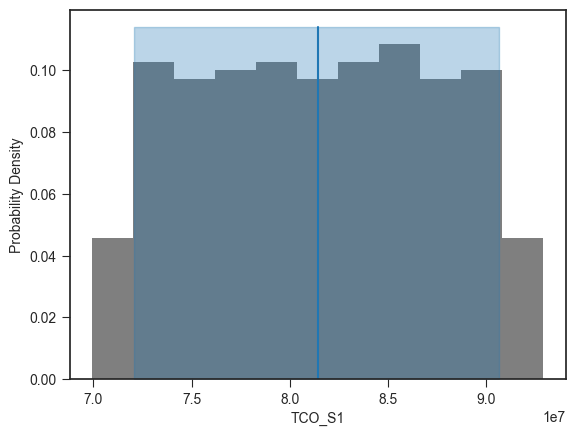

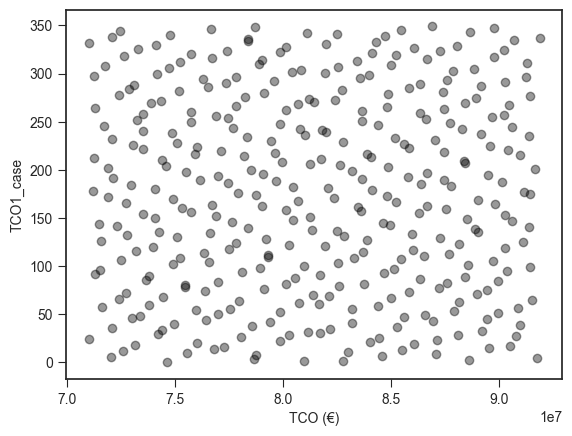

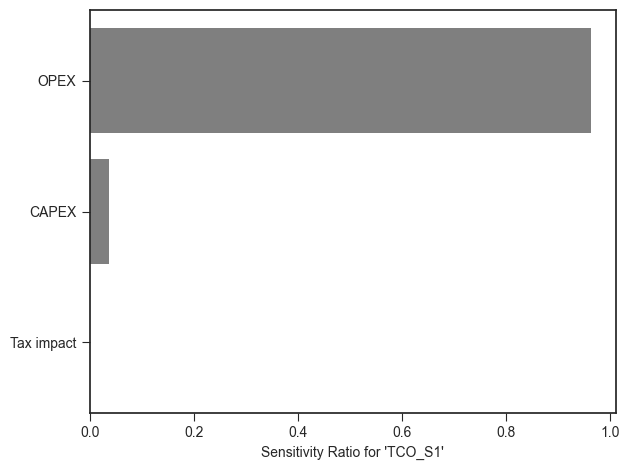

In [40]:
# ============================================================

# Monaco TCO S1 - Price range and sensitivity ratio

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S1 OPEX statistics

# ------------------------------------------------------------
 
AWE_S1_OPEX_STATS = make_stats(

    op_cost_S1_low,

    op_cost_S1_mean,

    op_cost_S1_high

)
 
print("AWE S1 OPEX distribution used for TCO Monte Carlo:")

print(AWE_S1_OPEX_STATS)
 
print("\nAWE CAPEX distribution used for TCO Monte Carlo:")

print(AWE_CAPEX_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(investment_cost, opr_cost, tax_impact):
 
    lcc_cost = monte_lcc(

        investment_cost=investment_cost,

        opr_cost=opr_cost,

        tax_impact=tax_impact

    )
 
    return (lcc_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess

# ------------------------------------------------------------
 
def preprocess(case):
 
    investment_cost = case.invals['CAPEX'].val

    opr_cost = case.invals['OPEX'].val

    tax_impact = case.invals['Tax impact'].val
 
    return (

        investment_cost,

        opr_cost,

        tax_impact

    )
 
 
# ------------------------------------------------------------

# 4. Postprocess

# ------------------------------------------------------------
 
def postprocess(case, lcc_cost):
 
    case.addOutVal(

        name='TCO_S1',

        val=lcc_cost

    )
 
    case.addOutVal(

        name='TCO1_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350

seed = 123456
 
 
sim = mc.Sim(

    name='Life Cycle Cost of H2_wos',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol_random',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Input distributions

# ------------------------------------------------------------
 
sim.addInVar(

    name='CAPEX',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_CAPEX_STATS

    )

)
 
 
sim.addInVar(

    name='OPEX',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_S1_OPEX_STATS

    )

)
 
 
# Existing tax-impact assumption retained

sim.addInVar(

    name='Tax impact',

    dist=uniform,

    distkwargs={

        'loc': 0,

        'scale': 1

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Statistics

# ------------------------------------------------------------
 
sim.outvars['TCO_S1'].addVarStat(

    'mean'

)
 
sim.outvars['TCO_S1'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S1 TCO samples

# ------------------------------------------------------------
 
awe_tco_s1_samples = np.asarray(

    sim.outvars['TCO_S1'].nums,

    dtype=float

).ravel()
 
awe_tco_s1_samples = awe_tco_s1_samples[

    np.isfinite(awe_tco_s1_samples)

]
 
 
print("\nAWE TCO S1 Monte Carlo check")

print("------------------------------")

print("N      :", len(awe_tco_s1_samples))

print("P5     :", np.percentile(awe_tco_s1_samples, 5))

print("Median :", np.median(awe_tco_s1_samples))

print("Mean   :", np.mean(awe_tco_s1_samples))

print("P95    :", np.percentile(awe_tco_s1_samples, 95))
 
 
# ------------------------------------------------------------

# 11. Plots

# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['TCO_S1']

)
 
mc.plot(

    sim.outvars['TCO_S1'],

    sim.outvars['TCO1_case']

)
 
plt.xlabel('TCO (€)')
 
 
# ------------------------------------------------------------

# 12. Existing local sensitivity

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('TCO_S1')
    sim.outvars['TCO_S1'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for TCO_S1 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...


AWE S2 OPEX distribution used for TCO Monte Carlo:
{'min': 52701039.47084686, 'mean': 58379489.9759603, 'max': 64128241.13322316, 'range': 11427201.6623763}

AWE CAPEX distribution used for TCO Monte Carlo:
{'min': 1113990.0967036327, 'mean': 1342695.4486529268, 'max': 1646688.2467915213, 'range': 532698.1500878886}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 285.42outvar/s]
Simulation complete! Runtime: 0:00:00.062507
Calculating sensitivity indices for 'TCO_S2'...
Calculating optimal hyperparameters Φ for 'TCO_S2' covariances...



AWE TCO S2 Monte Carlo check
------------------------------
N      : 350
P5     : 54654685.32871436
Median : 59780297.09792866
Mean   : 59801485.51299555
P95    : 64906404.166329466

AWE TCO S1 vs S2
------------------
S1 median: 81356932.155956
S2 median: 59780297.09792866
S1 - S2: 21576635.058027342


Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


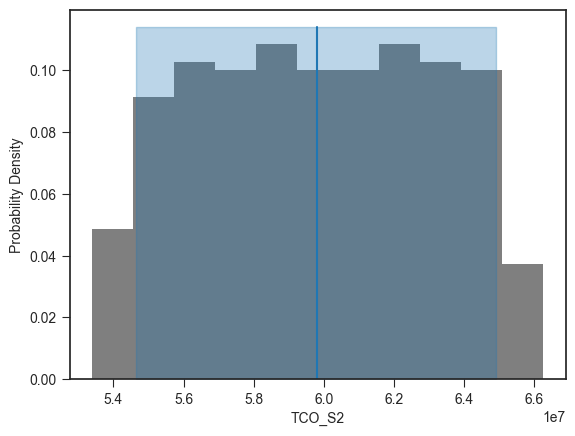

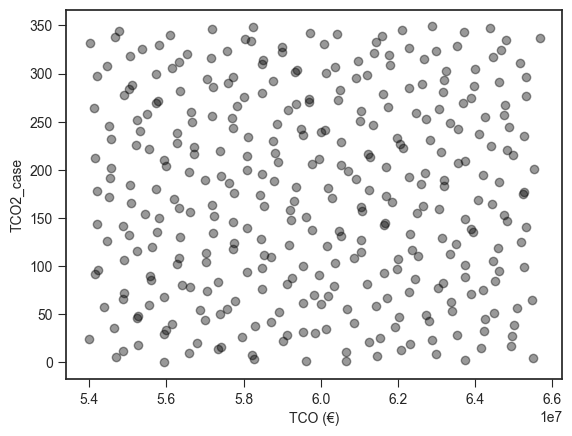

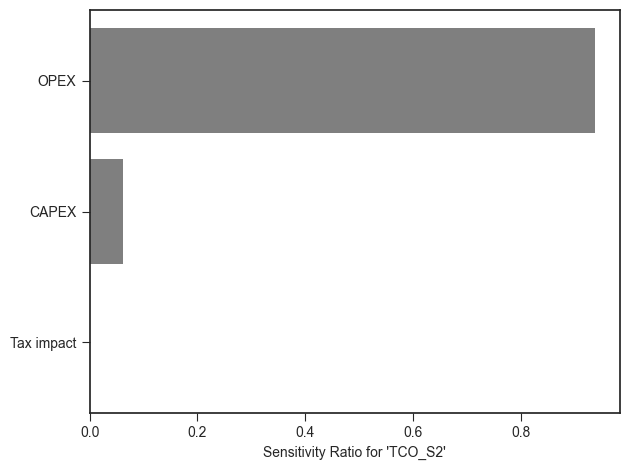

In [41]:
# ============================================================

# Monaco TCO S2 - Reference electricity-price scenario

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S2 OPEX statistics

# ------------------------------------------------------------
 
AWE_S2_OPEX_STATS = make_stats(

    op_cost_S2_low,

    op_cost_S2_mean,

    op_cost_S2_high

)
 
print("AWE S2 OPEX distribution used for TCO Monte Carlo:")

print(AWE_S2_OPEX_STATS)
 
print("\nAWE CAPEX distribution used for TCO Monte Carlo:")

print(AWE_CAPEX_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(investment_cost, opr_cost, tax_impact):
 
    lcc_cost = monte_lcc(

        investment_cost=investment_cost,

        opr_cost=opr_cost,

        tax_impact=tax_impact

    )
 
    return (lcc_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess

# ------------------------------------------------------------
 
def preprocess(case):
 
    investment_cost = case.invals['CAPEX'].val

    opr_cost = case.invals['OPEX'].val

    tax_impact = case.invals['Tax impact'].val
 
    return (

        investment_cost,

        opr_cost,

        tax_impact

    )
 
 
# ------------------------------------------------------------

# 4. Postprocess

# ------------------------------------------------------------
 
def postprocess(case, lcc_cost):
 
    case.addOutVal(

        name='TCO_S2',

        val=lcc_cost

    )
 
    case.addOutVal(

        name='TCO2_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350
 
# Same seed as S1

seed = 123456
 
 
sim = mc.Sim(

    name='Life Cycle Cost of H2_wos',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol_random',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Input distributions

# ------------------------------------------------------------
 
sim.addInVar(

    name='CAPEX',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_CAPEX_STATS

    )

)
 
 
sim.addInVar(

    name='OPEX',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_S2_OPEX_STATS

    )

)
 
 
sim.addInVar(

    name='Tax impact',

    dist=uniform,

    distkwargs={

        'loc': 0,

        'scale': 1

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Statistics

# ------------------------------------------------------------
 
sim.outvars['TCO_S2'].addVarStat(

    'mean'

)
 
sim.outvars['TCO_S2'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S2 TCO samples

# ------------------------------------------------------------
 
awe_tco_s2_samples = np.asarray(

    sim.outvars['TCO_S2'].nums,

    dtype=float

).ravel()
 
awe_tco_s2_samples = awe_tco_s2_samples[

    np.isfinite(awe_tco_s2_samples)

]
 
 
print("\nAWE TCO S2 Monte Carlo check")

print("------------------------------")

print("N      :", len(awe_tco_s2_samples))

print("P5     :", np.percentile(awe_tco_s2_samples, 5))

print("Median :", np.median(awe_tco_s2_samples))

print("Mean   :", np.mean(awe_tco_s2_samples))

print("P95    :", np.percentile(awe_tco_s2_samples, 95))
 
 
# ------------------------------------------------------------

# 11. S1 vs S2 consistency check

# ------------------------------------------------------------
 
print("\nAWE TCO S1 vs S2")

print("------------------")

print(

    "S1 median:",

    np.median(awe_tco_s1_samples)

)
 
print(

    "S2 median:",

    np.median(awe_tco_s2_samples)

)
 
print(

    "S1 - S2:",

    np.median(awe_tco_s1_samples)

    - np.median(awe_tco_s2_samples)

)
 
 
assert (

    np.median(awe_tco_s1_samples)
>

    np.median(awe_tco_s2_samples)

), (

    "ERROR: AWE S1 Monte Carlo TCO should be "

    "higher than AWE S2 Monte Carlo TCO."

)
 
 
# ------------------------------------------------------------

# 12. Plots

# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['TCO_S2']

)
 
mc.plot(

    sim.outvars['TCO_S2'],

    sim.outvars['TCO2_case']

)
 
plt.xlabel('TCO (€)')
 
 
# ------------------------------------------------------------

# 13. Existing local sensitivity

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('TCO_S2')
    sim.outvars['TCO_S2'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for TCO_S2 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


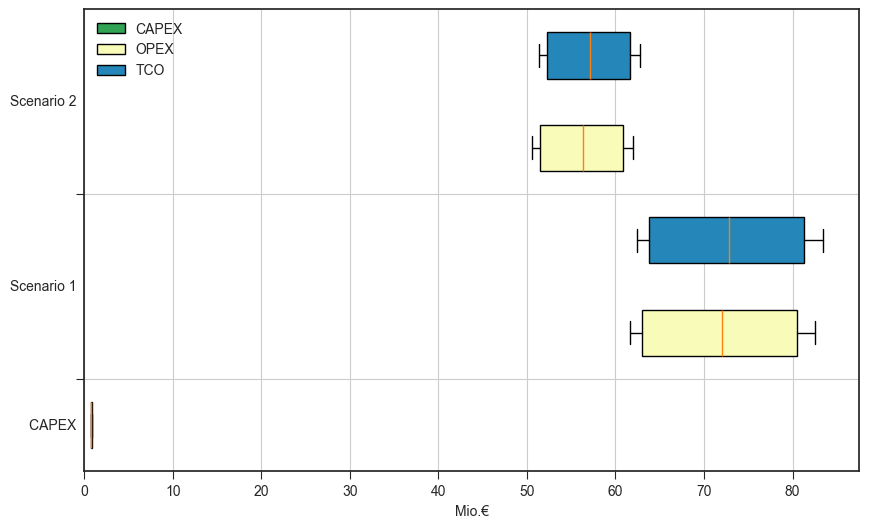

In [42]:
# Box plot - Results of CAPEX, OPEX and TCO - for manuscript

# Calcualted data from previous process
# p5 and p95 refer to the 5th and 95th percentiles respectively
# We use the p5 and p95 to plot a boxplot
# hard-coded plot summary values updated to new technology inputs
capex = {'min': 0.76, 'max': 0.86, 'median': 0.80, 'p5': 0.77, 'p95': 0.85}
opex_s1 = {'min': 61.6, 'max': 82.5, 'median': 72.0, 'p5': 63.0, 'p95': 80.5}
opex_s2 = {'min': 50.6, 'max': 62.0, 'median': 56.3, 'p5': 51.5, 'p95': 60.8}
tco_s1 = {'min': 62.4, 'max': 83.4, 'median': 72.8, 'p5': 63.8, 'p95': 81.3}
tco_s2 = {'min': 51.4, 'max': 62.8, 'median': 57.1, 'p5': 52.3, 'p95': 61.6}

# Draw the boxplot
plt.figure(figsize=(10, 6))

# Plotting the boxplot using the data defined above
bp = plt.boxplot(
    [[capex['min'], capex['p5'], capex['median'], capex['p95'], capex['max']],
    [opex_s1['min'], opex_s1['p5'], opex_s1['median'], opex_s1['p95'], opex_s1['max']],
    [tco_s1['min'], tco_s1['p5'], tco_s1['median'], tco_s1['p95'], tco_s1['max']],
    [opex_s2['min'], opex_s2['p5'], opex_s2['median'], opex_s2['p95'], opex_s2['max']],
    [tco_s2['min'], tco_s2['p5'], tco_s2['median'], tco_s2['p95'], tco_s2['max']]],
            labels=['CAPEX', 'OPEX S1', 'TCO S1', 'OPEX S2', 'TCO S2'], vert=False, patch_artist=True)

# Set color
colors = [(49/255, 163/255, 84/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255)]
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color)

legend_elements = [Patch(facecolor=(49/255, 163/255, 84/255), edgecolor='black', label='CAPEX'),
                   Patch(facecolor=(249/255, 252/255, 185/255), edgecolor='black', label='OPEX'),
                   Patch(facecolor=(36/255, 134/255, 185/255), edgecolor='black', label='TCO'),]

plt.legend(handles=legend_elements, loc='upper left')

# Define x-axis
plt.xlabel('Mio.€')

# Set y-axis
plt.xlim(0) 

plt.yticks([1.5, 3.5], ['', ''])

# Set lengend
plt.text(0, 1, 'CAPEX  ', ha='right', va='center')
plt.text(0, 2.5, 'Scenario 1  ', ha='right', va='center')
plt.text(0, 4.5, 'Scenario 2  ', ha='right', va='center')

# Print plot
plt.grid(True)
plt.show()


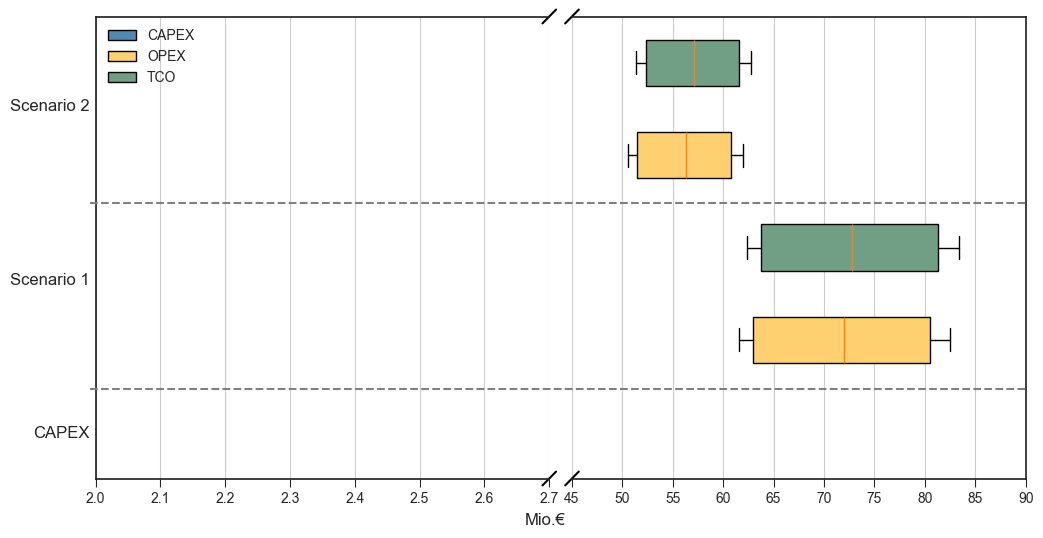

In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Calculated data
# hard-coded plot summary values updated to new technology inputs
capex = {'min': 0.76, 'max': 0.86, 'median': 0.80, 'p5': 0.77, 'p95': 0.85}
opex_s1 = {'min': 61.6, 'max': 82.5, 'median': 72.0, 'p5': 63.0, 'p95': 80.5}
opex_s2 = {'min': 50.6, 'max': 62.0, 'median': 56.3, 'p5': 51.5, 'p95': 60.8}
tco_s1 = {'min': 62.4, 'max': 83.4, 'median': 72.8, 'p5': 63.8, 'p95': 81.3}
tco_s2 = {'min': 51.4, 'max': 62.8, 'median': 57.1, 'p5': 52.3, 'p95': 61.6}

# Create a figure and a grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
fig.subplots_adjust(wspace=0.05)

# Data for the box plots
data1 = [
    [capex['min'], capex['p5'], capex['median'], capex['p95'], capex['max']],
    [],
    [],
    [],
    []
]
data2 = [
    [],
    [opex_s1['min'], opex_s1['p5'], opex_s1['median'], opex_s1['p95'], opex_s1['max']],
    [tco_s1['min'], tco_s1['p5'], tco_s1['median'], tco_s1['p95'], tco_s1['max']],
    [opex_s2['min'], opex_s2['p5'], opex_s2['median'], opex_s2['p95'], opex_s2['max']],
    [tco_s2['min'], tco_s2['p5'], tco_s2['median'], tco_s2['p95'], tco_s2['max']]
]

# Plotting the box plots on both axes with colors
bp1 = ax1.boxplot(data1, vert=False, patch_artist=True)
bp2 = ax2.boxplot(data2, vert=False, patch_artist=True)

# Setting colors for the boxes in ax1
colors1 = [(80/255, 138/255, 178/255)] * 5  # CAPEX color for all boxes
for box, color in zip(bp1['boxes'], colors1):
    box.set(facecolor=color)

# Setting colors for the boxes in ax2
colors2 = [(255/255, 255/255, 255/255), (255/255, 208/255, 111/255), (113/255, 159/255, 133/255), (255/255, 208/255, 111/255), (113/255, 159/255, 133/255)]
for box, color in zip(bp2['boxes'], colors2):
    box.set(facecolor=color)

# Setting the limits for the x-axes
ax1.set_xlim(2, 2.7)
ax2.set_xlim(45, 90)

# Removing y-axis ticks and labels for both axes
ax1.yaxis.set_visible(False)
ax2.yaxis.set_visible(False)

# Removing the spines between the axes
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Adding diagonal lines to indicate the broken axis
d = .015  # size of the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)  # top-left diagonal

# Adding horizontal lines between ax1 and ax2
line_y = 0.26  # y-coordinate for the line
line_color = 'gray'
line_style = '--'
fig.add_artist(plt.Line2D([0.12, 0.9], [line_y, line_y], transform=fig.transFigure, color=line_color, linestyle=line_style))

# Adding horizontal lines between ax2 and ax3
line_y = 0.57  # y-coordinate for the line
fig.add_artist(plt.Line2D([0.12, 0.9], [line_y, line_y], transform=fig.transFigure, color=line_color, linestyle=line_style))

# Set legend
legend_elements = [
    Patch(facecolor=(80/255, 138/255, 178/255), edgecolor='black', label='CAPEX'),
    Patch(facecolor=(255/255, 208/255, 111/255), edgecolor='black', label='OPEX'),
    Patch(facecolor=(113/255, 159/255, 133/255), edgecolor='black', label='TCO')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Adding labels using fig.text() to position them relative to the figure
fig.text(0.5,0.04, 'Mio.€', ha='center', va='center', fontsize=12)

fig.text(0.12, 0.185, 'CAPEX', ha='right', va='center', fontsize=12)
fig.text(0.12, 0.44, 'Scenario 1', ha='right', va='center', fontsize=12)
fig.text(0.12, 0.73, 'Scenario 2', ha='right', va='center', fontsize=12)

# Show plot
ax1.grid(True)
ax2.grid(True)
plt.show()


In [44]:
fig.legend(handles=legend_elements, loc='upper left')


In [45]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_mean

# LCC S1 (Mean) is calculated here based on all the parameters listed below
kwargs = {
    'equity': 0.25,
    'eq_rate_return': 0.07,
    'debt': 0.75,
    'db_intrst_rate': 0.045,
    'inflation_rate': 0.01
}

lcoh_s1_mean = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_mean,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_mean:.2f}")


In [46]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_higher

# LCC S1 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_high = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_high,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_high:.2f}")


In [47]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_low

# LCC S1 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_low = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_low,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_low:.2f}")


In [48]:
# LCOH S2
# with LCC_S2_mean

# LCC S2 (Mean) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_mean = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_mean,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_mean:.2f}")


In [49]:
# ============================================================
# Component-specific CAPEX stress-test function
# ============================================================

import numpy as np
import pandas as pd

PRICE_SHOCKS = [-0.50, -0.25, 0.25, 0.50, 1.00]


def component_capex_stress_test(
    component_costs,
    selected_components,
    baseline_material_cost,
    baseline_capex,
    baseline_tco,
    baseline_lcoh,
    h2_production,
    technology,
    threshold=4.0,
    shocks=PRICE_SHOCKS
):
    """
    Component-specific CAPEX-channel stress test.

    Only CAPEX is changed.
    OPEX and other lifecycle-cost terms are held constant
    in order to isolate the CAPEX channel.

    Parameters
    ----------
    component_costs : dict
        Baseline total cost of each material/component (€).

    selected_components : list
        Components to stress.

    baseline_material_cost : float
        Total baseline material/component cost (€).

    baseline_capex : float
        Baseline investment cost (€).

    baseline_tco : float
        Baseline S2 life-cycle cost / TCO (€).

    baseline_lcoh : float
        Baseline S2 LCOH (€/kg H2).

    h2_production : float
        Lifetime hydrogen production used in the LCOH model.

    technology : str
        'AWE' or 'PEMWE'.

    threshold : float
        Deployment benchmark (€/kg H2).

    shocks : list
        Relative component-price changes.
        Example: 0.50 = +50%; -0.50 = -50%.
    """

    results = []

    # Explicit financial parameters used in the current model
    financial_kwargs = {
        'equity': 0.25,
        'eq_rate_return': 0.07,
        'debt': 0.75,
        'db_intrst_rate': 0.045,
        'inflation_rate': 0.01
    }

    for component in selected_components:

        base_component_cost = float(
            component_costs[component]
        )

        for shock in shocks:

            # New component contribution
            stressed_component_cost = (
                base_component_cost * (1 + shock)
            )

            # Change in total material cost
            delta_material_cost = (
                stressed_component_cost
                - base_component_cost
            )

            stressed_material_cost = (
                baseline_material_cost
                + delta_material_cost
            )

            # CAPEX in the current model:
            # material + construction labour
            # construction labour = 20.8% of material cost
            stressed_capex = stressed_material_cost * 1.208

            delta_capex = (
                stressed_capex
                - baseline_capex
            )

            # Isolated CAPEX channel:
            # OPEX and other lifecycle terms remain fixed
            stressed_tco = (
                baseline_tco
                + delta_capex
            )

            stressed_lcoh = levelized_cost_of_h2(
                life_cycle_cost_of_h2=stressed_tco,
                h2_production=h2_production,
                **financial_kwargs
            )

            results.append({
                'Technology': technology,
                'Component': component,
                'Price shock (%)': shock * 100,

                'Baseline component cost (€)':
                    base_component_cost,

                'Stressed component cost (€)':
                    stressed_component_cost,

                'Baseline CAPEX (€)':
                    baseline_capex,

                'Stressed CAPEX (€)':
                    stressed_capex,

                'ΔCAPEX (€)':
                    delta_capex,

                'ΔCAPEX (%)':
                    (stressed_capex / baseline_capex - 1) * 100,

                'Baseline LCOH (€/kg H2)':
                    baseline_lcoh,

                'Stressed LCOH (€/kg H2)':
                    stressed_lcoh,

                'ΔLCOH (€/kg H2)':
                    stressed_lcoh - baseline_lcoh,

                'LCOH change (%)':
                    (stressed_lcoh / baseline_lcoh - 1) * 100,

                'Gap to threshold (€/kg H2)':
                    stressed_lcoh - threshold
            })

    return pd.DataFrame(results)


In [50]:
awe_components_for_stress = [
    'Rectifier / power electronics',
    'PTFE',
    'Zirfon Membrane',
    'Nickel'
]

awe_stress_results = component_capex_stress_test(
    component_costs=awe_component_costs,
    selected_components=awe_components_for_stress,
    baseline_material_cost=awe_material_cost_base,
    baseline_capex=awe_capex_base,
    baseline_tco=lcc_S2_mean,
    baseline_lcoh=lcoh_s2_mean,
    h2_production=19588000,
    technology='AWE',
    threshold=4.0
)

print(
    awe_stress_results[
        [
            'Component',
            'Price shock (%)',
            'ΔCAPEX (%)',
            'Stressed LCOH (€/kg H2)',
            'ΔLCOH (€/kg H2)',
            'Gap to threshold (€/kg H2)'
        ]
    ].round(3).to_string(index=False)
)


                    Component      Price shock (%)           ΔCAPEX (%)  Stressed LCOH (€/kg H2)      ΔLCOH (€/kg H2)  Gap to threshold (€/kg H2)
Rectifier / power electronics              -50.000              -17.767                    7.434               -0.025                       3.434
Rectifier / power electronics              -25.000               -8.883                    7.446               -0.012                       3.446
Rectifier / power electronics               25.000                8.883                    7.471                0.012                       3.471
Rectifier / power electronics               50.000               17.767                    7.484                0.025                       3.484
Rectifier / power electronics              100.000               35.534                    7.509                0.050                       3.509
                         PTFE              -50.000              -14.172                    7.439               -0.020       

In [51]:
# LCOH S2
# with LCC_S2_higher

# LCC S2 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_high = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_high,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_high:.2f}")


In [52]:
# LCOH S2
# with LCC_S2_lower

# LCC S2 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_low = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_low,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_low:.2f}")


In [53]:
# Threshold robustness analysis for Monte Carlo LCOH S2
# The function is defined before the LCOH Monte Carlo simulations, but it is only
# called after sim.runSim(), when sim.outvars['LCOH_S2'] is available.
THRESHOLDS = [3.5, 4.0, 4.5, 5.0]

def threshold_robustness(
    lcoh_samples,
    technology,
    thresholds=THRESHOLDS,
    scenario="Reference electricity-price scenario"
):
    lcoh = np.asarray(lcoh_samples, dtype=float).ravel()
    lcoh = lcoh[np.isfinite(lcoh)]

    if len(lcoh) == 0:
        raise ValueError("No valid LCOH samples found.")

    results = []

    for threshold in thresholds:
        gap = lcoh - threshold
        crossed = lcoh <= threshold

        results.append({
            "Technology": technology,
            "Scenario": scenario,
            "Threshold (€/kg H2)": threshold,
            "N cases": len(lcoh),
            "Crossed cases": int(np.sum(crossed)),
            "Pcross (%)": np.mean(crossed) * 100,
            "Median gap (€/kg H2)": np.median(gap),
            "P5 gap (€/kg H2)": np.percentile(gap, 5),
            "P95 gap (€/kg H2)": np.percentile(gap, 95),
        })

    return pd.DataFrame(results)


Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method...
Done
Generating cases...


AWE S1 TCO distribution used for LCOH Monte Carlo:
{'min': 70797037.81245695, 'mean': 81111755.55922036, 'max': 91523748.73807277, 'range': 20726710.925615817}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 657.72outvar/s]
Simulation complete! Runtime: 0:00:00.051929
Calculating sensitivity indices for 'LCOH_S1'...



AWE LCOH S1 check
-------------------
N      : 350
Min    : 6.359516546349627
P5     : 7.1795964354688975
Median : 8.670592686005772
Mean   : 8.742774952464101
P95    : 10.636491357313206
Max    : 11.98740616422003


Calculating optimal hyperparameters Φ for 'LCOH_S1' covariances...


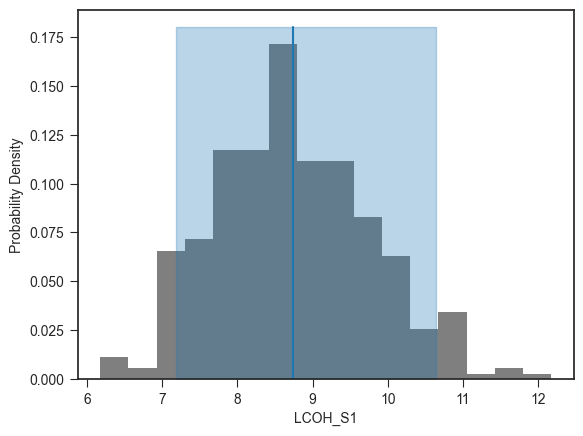

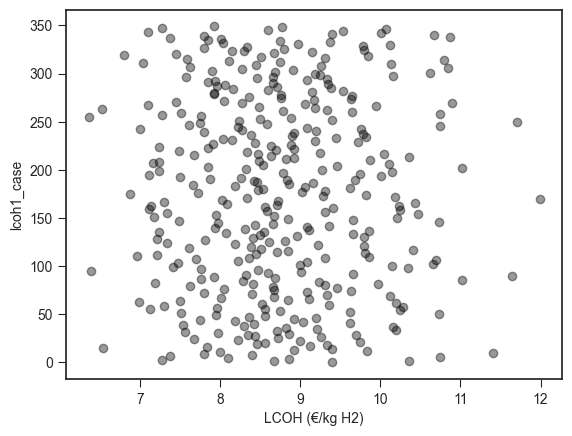

In [54]:
# ============================================================

# Monaco LCOH S1 - Price range and sensitivity ratio

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S1 TCO statistics

# ------------------------------------------------------------
 
AWE_S1_TCO_STATS = make_stats(

    lcc_S1_low,

    lcc_S1_mean,

    lcc_S1_high

)
 
print("AWE S1 TCO distribution used for LCOH Monte Carlo:")

print(AWE_S1_TCO_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(

    life_cycle_cost_of_h2,

    h2_production,

    equity,

    eq_rate_return,

    debt,

    db_intrst_rate,

    inflation_rate

):
 
    kwargs = {

        'inflation_rate': inflation_rate,

        'equity': equity,

        'eq_rate_return': eq_rate_return,

        'debt': debt,

        'db_intrst_rate': db_intrst_rate,

    }
 
    lcoh_cost = levelized_cost_of_h2(

        life_cycle_cost_of_h2=life_cycle_cost_of_h2,

        h2_production=h2_production,

        **kwargs

    )
 
    return (lcoh_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess

# ------------------------------------------------------------
 
def preprocess(case):
 
    life_cycle_cost_of_h2 = (

        case.invals['life_cycle_cost_of_h2'].val

    )
 
    h2_production = (

        case.invals['h2_production'].val

    )
 
    equity = case.invals['equity'].val
 
    eq_rate_return = (

        case.invals['eq_rate_return'].val

    )
 
    debt = case.invals['debt'].val
 
    db_intrst_rate = (

        case.invals['db_intrst_rate'].val

    )
 
    inflation_rate = (

        case.invals['inflation_rate'].val

    )
 
    return (

        life_cycle_cost_of_h2,

        h2_production,

        equity,

        eq_rate_return,

        debt,

        db_intrst_rate,

        inflation_rate

    )
 
 
# ------------------------------------------------------------

# 4. Postprocess

# ------------------------------------------------------------
 
def postprocess(case, lcoh_cost):
 
    case.addOutVal(

        name='LCOH_S1',

        val=lcoh_cost

    )
 
    case.addOutVal(

        name='lcoh1_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350

seed = 123456
 
 
sim = mc.Sim(

    name='LCOH',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Input distributions

# ------------------------------------------------------------
 
# CURRENT S1 TCO distribution

sim.addInVar(

    name='life_cycle_cost_of_h2',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_S1_TCO_STATS

    )

)
 
 
# Existing AWE hydrogen-production uncertainty retained

sim.addInVar(

    name='h2_production',

    dist=uniform,

    distkwargs={

        'loc': 18000000,

        'scale': 4000000

    }

)
 
 
sim.addInVar(

    name='equity',

    dist=uniform,

    distkwargs={

        'loc': 0.15,

        'scale': 0.10

    }

)
 
 
sim.addInVar(

    name='eq_rate_return',

    dist=uniform,

    distkwargs={

        'loc': 0.05,

        'scale': 0.01

    }

)
 
 
sim.addInVar(

    name='debt',

    dist=uniform,

    distkwargs={

        'loc': 0.75,

        'scale': 0.01

    }

)
 
 
sim.addInVar(

    name='db_intrst_rate',

    dist=uniform,

    distkwargs={

        'loc': 0.045,

        'scale': 0.005

    }

)
 
 
sim.addInVar(

    name='inflation_rate',

    dist=uniform,

    distkwargs={

        'loc': 0.01,

        'scale': 0.05

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Statistics

# ------------------------------------------------------------
 
sim.outvars['LCOH_S1'].addVarStat(

    'mean'

)
 
sim.outvars['LCOH_S1'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S1 samples

# ------------------------------------------------------------
 
awe_lcoh_s1 = np.asarray(

    sim.outvars['LCOH_S1'].nums,

    dtype=float

).ravel()
 
awe_lcoh_s1 = awe_lcoh_s1[

    np.isfinite(awe_lcoh_s1)

]
 
 
print("\nAWE LCOH S1 check")

print("-------------------")

print("N      :", len(awe_lcoh_s1))

print("Min    :", np.min(awe_lcoh_s1))

print("P5     :", np.percentile(awe_lcoh_s1, 5))

print("Median :", np.median(awe_lcoh_s1))

print("Mean   :", np.mean(awe_lcoh_s1))

print("P95    :", np.percentile(awe_lcoh_s1, 95))

print("Max    :", np.max(awe_lcoh_s1))
 
 
# ------------------------------------------------------------

# 11. Plots

# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['LCOH_S1']

)
 
mc.plot(

    sim.outvars['LCOH_S1'],

    sim.outvars['lcoh1_case']

)
 
plt.xlabel('LCOH (€/kg H2)')
 
 
# ------------------------------------------------------------

# 12. Existing local sensitivity

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('LCOH_S1')
    sim.outvars['LCOH_S1'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for LCOH_S1 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method...
Done
Generating cases...


AWE S2 TCO distribution used for LCOH Monte Carlo:
{'min': 53822903.5728196, 'mean': 59501354.077933036, 'max': 65250105.2351959, 'range': 11427201.6623763}


Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 663.55outvar/s]
Simulation complete! Runtime: 0:00:00.049924
Calculating sensitivity indices for 'LCOH_S2'...
Calculating optimal hyperparameters Φ for 'LCOH_S2' covariances...



AWE LCOH S2 check
-------------------
N      : 350
Min    : 4.8332558963942285
P5     : 5.359172505941647
Median : 6.359494709581755
Mean   : 6.413239374557101
P95    : 7.628449864755388
Max    : 8.54790703925796

AWE S2 threshold robustness
--------------------------------
Technology                                  Scenario  Threshold (€/kg H2)  N cases  Crossed cases           Pcross (%)  Median gap (€/kg H2)     P5 gap (€/kg H2)    P95 gap (€/kg H2)
       AWE Reference electricity-price scenario (S2)                3.500      350              0                0.000                 2.860                1.859                4.128
       AWE Reference electricity-price scenario (S2)                4.000      350              0                0.000                 2.360                1.359                3.628
       AWE Reference electricity-price scenario (S2)                4.500      350              0                0.000                 1.859                0.859              

Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


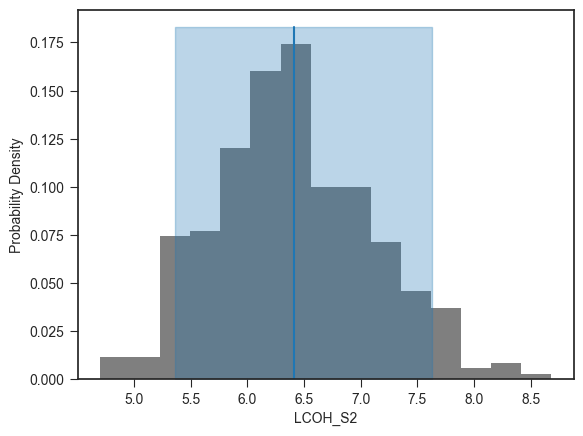

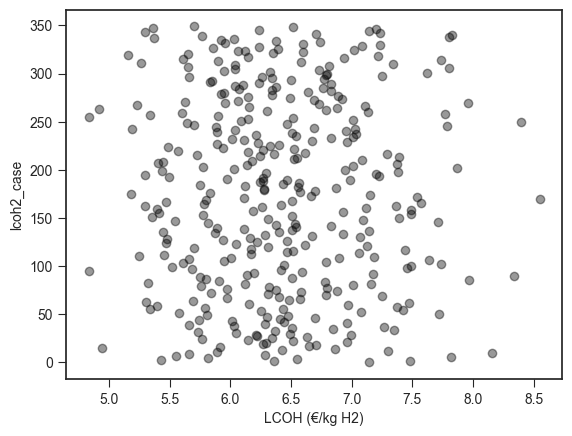

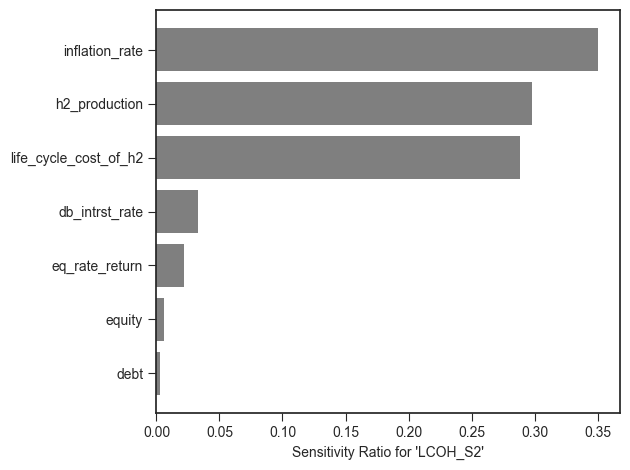

In [55]:
# ============================================================

# Monaco LCOH S2 - Price range and sensitivity ratio

# ============================================================
 
 
# ------------------------------------------------------------

# 1. Build CURRENT S2 TCO statistics

# ------------------------------------------------------------
 
AWE_S2_TCO_STATS = make_stats(

    lcc_S2_low,

    lcc_S2_mean,

    lcc_S2_high

)
 
print("AWE S2 TCO distribution used for LCOH Monte Carlo:")

print(AWE_S2_TCO_STATS)
 
 
# ------------------------------------------------------------

# 2. Monte Carlo model

# ------------------------------------------------------------
 
def run(

    life_cycle_cost_of_h2,

    h2_production,

    equity,

    eq_rate_return,

    debt,

    db_intrst_rate,

    inflation_rate

):
 
    kwargs = {

        'inflation_rate': inflation_rate,

        'equity': equity,

        'eq_rate_return': eq_rate_return,

        'debt': debt,

        'db_intrst_rate': db_intrst_rate,

    }
 
    lcoh_cost = levelized_cost_of_h2(

        life_cycle_cost_of_h2=life_cycle_cost_of_h2,

        h2_production=h2_production,

        **kwargs

    )
 
    return (lcoh_cost,)
 
 
# ------------------------------------------------------------

# 3. Preprocess

# ------------------------------------------------------------
 
def preprocess(case):
 
    life_cycle_cost_of_h2 = (

        case.invals['life_cycle_cost_of_h2'].val

    )
 
    h2_production = (

        case.invals['h2_production'].val

    )
 
    equity = case.invals['equity'].val
 
    eq_rate_return = (

        case.invals['eq_rate_return'].val

    )
 
    debt = case.invals['debt'].val
 
    db_intrst_rate = (

        case.invals['db_intrst_rate'].val

    )
 
    inflation_rate = (

        case.invals['inflation_rate'].val

    )
 
    return (

        life_cycle_cost_of_h2,

        h2_production,

        equity,

        eq_rate_return,

        debt,

        db_intrst_rate,

        inflation_rate

    )
 
 
# ------------------------------------------------------------

# 4. Postprocess

# ------------------------------------------------------------
 
def postprocess(case, lcoh_cost):
 
    case.addOutVal(

        name='LCOH_S2',

        val=lcoh_cost

    )
 
    case.addOutVal(

        name='lcoh2_case',

        val=case.ncase

    )
 
    return None
 
 
# ------------------------------------------------------------

# 5. Functions

# ------------------------------------------------------------
 
fcns = {

    'run': run,

    'preprocess': preprocess,

    'postprocess': postprocess

}
 
 
# ------------------------------------------------------------

# 6. Monte Carlo configuration

# ------------------------------------------------------------
 
n_invests = 350

seed = 123456
 
 
sim = mc.Sim(

    name='LCOH',

    ndraws=n_invests,

    fcns=fcns,

    seed=seed,

    samplemethod='sobol',

    singlethreaded=True,

    savecasedata=False,

    verbose=True,

    debug=True

)
 
 
# ------------------------------------------------------------

# 7. Input distributions

# ------------------------------------------------------------
 
# CURRENT S2 TCO distribution

sim.addInVar(

    name='life_cycle_cost_of_h2',

    dist=uniform,

    distkwargs=uniform_from_stats(

        AWE_S2_TCO_STATS

    )

)
 
 
# Existing AWE hydrogen-production uncertainty retained

sim.addInVar(

    name='h2_production',

    dist=uniform,

    distkwargs={

        'loc': 18000000,

        'scale': 4000000

    }

)
 
 
sim.addInVar(

    name='equity',

    dist=uniform,

    distkwargs={

        'loc': 0.15,

        'scale': 0.10

    }

)
 
 
sim.addInVar(

    name='eq_rate_return',

    dist=uniform,

    distkwargs={

        'loc': 0.05,

        'scale': 0.01

    }

)
 
 
sim.addInVar(

    name='debt',

    dist=uniform,

    distkwargs={

        'loc': 0.75,

        'scale': 0.01

    }

)
 
 
sim.addInVar(

    name='db_intrst_rate',

    dist=uniform,

    distkwargs={

        'loc': 0.045,

        'scale': 0.005

    }

)
 
 
sim.addInVar(

    name='inflation_rate',

    dist=uniform,

    distkwargs={

        'loc': 0.01,

        'scale': 0.05

    }

)
 
 
# ------------------------------------------------------------

# 8. Run simulation

# ------------------------------------------------------------
 
sim.runSim()
 
 
# ------------------------------------------------------------

# 9. Statistics

# ------------------------------------------------------------
 
sim.outvars['LCOH_S2'].addVarStat(

    'mean'

)
 
sim.outvars['LCOH_S2'].addVarStat(

    'percentile',

    {'p': [0.05, 0.95]}

)
 
 
# ------------------------------------------------------------

# 10. Save S2 samples

# ------------------------------------------------------------
 
awe_lcoh_s2 = np.asarray(

    sim.outvars['LCOH_S2'].nums,

    dtype=float

).ravel()
 
awe_lcoh_s2 = awe_lcoh_s2[

    np.isfinite(awe_lcoh_s2)

]
 
 
print("\nAWE LCOH S2 check")

print("-------------------")

print("N      :", len(awe_lcoh_s2))

print("Min    :", np.min(awe_lcoh_s2))

print("P5     :", np.percentile(awe_lcoh_s2, 5))

print("Median :", np.median(awe_lcoh_s2))

print("Mean   :", np.mean(awe_lcoh_s2))

print("P95    :", np.percentile(awe_lcoh_s2, 95))

print("Max    :", np.max(awe_lcoh_s2))
 
 

# ------------------------------------------------------------
# 11. Threshold robustness and S1/S2 sanity check
# ------------------------------------------------------------

awe_threshold_results = threshold_robustness(
    lcoh_samples=awe_lcoh_s2,
    technology="AWE",
    scenario="Reference electricity-price scenario (S2)"
)

print("\nAWE S2 threshold robustness")
print("--------------------------------")
print(awe_threshold_results.round(4).to_string(index=False))

print("\nAWE LCOH S1 vs S2")
print("----------------------")
print("S1 median:", np.median(awe_lcoh_s1))
print("S2 median:", np.median(awe_lcoh_s2))
print("S1 - S2 :", np.median(awe_lcoh_s1) - np.median(awe_lcoh_s2))

assert (
    np.median(awe_lcoh_s1) > np.median(awe_lcoh_s2)
), (
    "ERROR: AWE S1 Monte Carlo LCOH should be higher than "
    "AWE S2 Monte Carlo LCOH."
)


# ------------------------------------------------------------
# 12. Plots
# ------------------------------------------------------------


# ------------------------------------------------------------
 
mc.plot(

    sim.outvars['LCOH_S2']

)
 
mc.plot(

    sim.outvars['LCOH_S2'],

    sim.outvars['lcoh2_case']

)
 
plt.xlabel('LCOH (€/kg H2)')
 
 
# ------------------------------------------------------------

# 13. Existing local sensitivity

# ------------------------------------------------------------
 
try:
    sim.calcSensitivities('LCOH_S2')
    sim.outvars['LCOH_S2'].plotSensitivities()
except Exception as exc:
    print(
        "WARNING: Monaco sensitivity analysis for LCOH_S2 was skipped "
        f"because {type(exc).__name__}: {exc}"
    )


In [56]:
# Legacy hard-coded manuscript boxplot disabled.
# The final cell now generates all paper figures directly from the live Monte Carlo outputs.


In [57]:
# Legacy hard-coded literature-validation plot disabled to avoid mixing stale LCOH ranges
# with the current scenario-specific Monte Carlo results.
# If literature validation is needed later, regenerate it from the final live summary table.


## Paper-ready result export and figures
Run the complete notebook first. This final cell exports live result tables and publication-ready figures for the paper.



Paper-ready summary
Technology         Metric Scenario        Deterministic                   P5               Median                 Mean                  P95                    N
       AWE       OPEX (€)       S1       79,989,891.457       69,675,173.711       79,989,891.457       79,989,891.457       90,401,884.636                  NaN
       AWE       OPEX (€)       S2       58,379,489.976       52,701,039.471       58,379,489.976       58,379,489.976       64,128,241.133                  NaN
       AWE        TCO (€)       S1       81,111,755.559       72,089,098.107       81,356,932.156       81,430,718.199       90,647,842.576              350.000
       AWE        TCO (€)       S2       59,501,354.078       54,654,685.329       59,780,297.098       59,801,485.513       64,906,404.166              350.000
       AWE LCOH (€/kg H2)       S1               10.168                7.180                8.671                8.743               10.636              350.000
       AWE LC

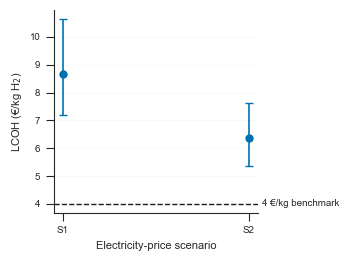

Saved: c:\AWS\LCA\joule_figures\AWE_Fig02_OPEX_scenarios.png
Saved: c:\AWS\LCA\joule_figures\AWE_Fig02_OPEX_scenarios.pdf


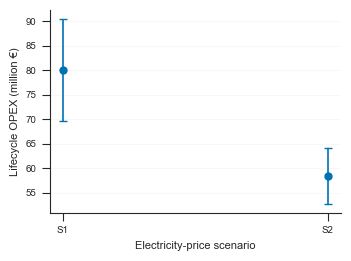

Saved: c:\AWS\LCA\joule_figures\AWE_Fig03_threshold_crossing.png
Saved: c:\AWS\LCA\joule_figures\AWE_Fig03_threshold_crossing.pdf


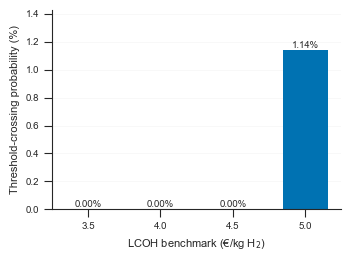

Saved: c:\AWS\LCA\joule_figures\AWE_Fig04_component_stress_LCOH.png
Saved: c:\AWS\LCA\joule_figures\AWE_Fig04_component_stress_LCOH.pdf


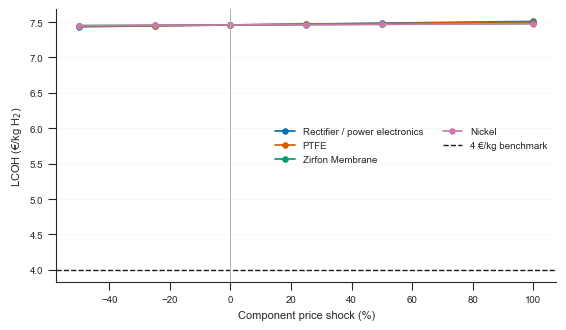

Saved: c:\AWS\LCA\joule_figures\AWE_Fig05_component_stress_CAPEX.png
Saved: c:\AWS\LCA\joule_figures\AWE_Fig05_component_stress_CAPEX.pdf


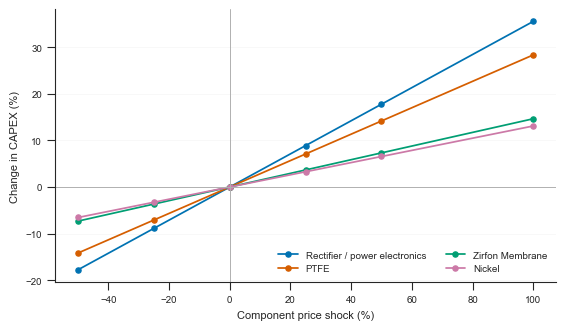

Saved: c:\AWS\LCA\joule_figures\AWE_Fig06_material_cost_structure.png
Saved: c:\AWS\LCA\joule_figures\AWE_Fig06_material_cost_structure.pdf


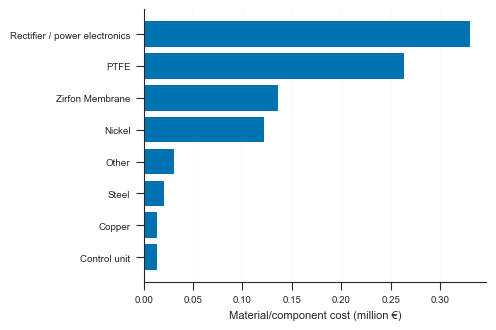


All paper figures and CSV tables were exported to:
c:\AWS\LCA\joule_figures


In [58]:
# ============================================================
# PAPER-READY FIGURES AND RESULT EXPORTS
# Run this cell LAST, after the complete notebook has run.
#
# Clean, Joule/Cell Press-inspired styling:
# - white background
# - restrained color palette
# - no chart titles inside the figure
# - vector PDF + 600 dpi PNG export
# - all values are read from the LIVE model/simulation outputs
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TECHNOLOGY = "AWE"
TECH_COLOR = "#0072B2"
S1_COLOR = "#4D4D4D"
S2_COLOR = TECH_COLOR
BENCHMARK_COLOR = "#1A1A1A"
COMPONENT_COLORS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#7F7F7F"]

FIG_DIR = Path.cwd() / "joule_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
})

def _clean_axis(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis is not None:
        ax.grid(axis=grid_axis, linewidth=0.45, alpha=0.22)
        ax.set_axisbelow(True)

def _save_figure(fig, stem):
    png = FIG_DIR / f"{TECHNOLOGY}_{stem}.png"
    pdf = FIG_DIR / f"{TECHNOLOGY}_{stem}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)

def _summary_stats(values):
    arr = np.asarray(values, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    return {
        "P5": np.percentile(arr, 5),
        "Median": np.median(arr),
        "Mean": np.mean(arr),
        "P95": np.percentile(arr, 95),
        "N": len(arr),
    }

required = [
    "awe_tco_s1_samples",
    "awe_tco_s2_samples",
    "awe_lcoh_s1",
    "awe_lcoh_s2",
    "awe_threshold_results",
    "awe_stress_results",
    "awe_component_table",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the full notebook before the paper-figure cell. "
        "Missing variables: " + ", ".join(missing)
    )

# ------------------------------------------------------------
# Export a compact table of all paper-relevant Monte Carlo stats
# ------------------------------------------------------------
summary_rows = []
# Lifecycle OPEX is exported from the active operation_cost() scenario
# calculations (low / mean / high). This keeps the publication summary
# consistent with the deterministic lifecycle-cost model.
for scenario, low_v, mean_v, high_v in [
    ("S1", op_cost_S1_low, op_cost_S1_mean, op_cost_S1_high),
    ("S2", op_cost_S2_low, op_cost_S2_mean, op_cost_S2_high),
]:
    summary_rows.append({
        "Technology": TECHNOLOGY,
        "Metric": "OPEX (€)",
        "Scenario": scenario,
        "Deterministic": float(mean_v),
        "P5": float(low_v),
        "Median": float(mean_v),
        "Mean": float(mean_v),
        "P95": float(high_v),
        "N": np.nan,
    })

for metric, scenario, values, deterministic in [
    ("TCO (€)", "S1", awe_tco_s1_samples, lcc_S1_mean),
    ("TCO (€)", "S2", awe_tco_s2_samples, lcc_S2_mean),
    ("LCOH (€/kg H2)", "S1", awe_lcoh_s1, lcoh_s1_mean),
    ("LCOH (€/kg H2)", "S2", awe_lcoh_s2, lcoh_s2_mean),
]:
    stats = _summary_stats(values)
    summary_rows.append({
        "Technology": TECHNOLOGY,
        "Metric": metric,
        "Scenario": scenario,
        "Deterministic": float(deterministic),
        **stats,
    })

paper_summary = pd.DataFrame(summary_rows)
paper_summary.to_csv(FIG_DIR / f"{TECHNOLOGY}_paper_summary.csv", index=False)
awe_threshold_results.to_csv(FIG_DIR / f"{TECHNOLOGY}_threshold_results.csv", index=False)
awe_stress_results.to_csv(FIG_DIR / f"{TECHNOLOGY}_stress_results.csv", index=False)
awe_component_table.to_csv(FIG_DIR / f"{TECHNOLOGY}_material_components.csv", index=False)

print("\nPaper-ready summary")
print(paper_summary.round(4).to_string(index=False))

# Final consistency checks
assert op_cost_S1_mean > op_cost_S2_mean
assert np.median(awe_tco_s1_samples) > np.median(awe_tco_s2_samples)
assert np.median(awe_lcoh_s1) > np.median(awe_lcoh_s2)
print("\nScenario-order checks passed: S1 > S2 for lifecycle OPEX, TCO and LCOH.")

# ============================================================
# FIGURE 1 — Scenario effect on LCOH
# Median with P5–P95 uncertainty interval + 4 €/kg benchmark
# ============================================================
s1 = _summary_stats(awe_lcoh_s1)
s2 = _summary_stats(awe_lcoh_s2)

fig, ax = plt.subplots(figsize=(3.55, 2.65))
x = np.array([0, 1])
med = np.array([s1["Median"], s2["Median"]])
low = med - np.array([s1["P5"], s2["P5"]])
high = np.array([s1["P95"], s2["P95"]]) - med

ax.errorbar(
    x, med, yerr=np.vstack([low, high]),
    fmt="o", markersize=5.0, capsize=3,
    color=TECH_COLOR, ecolor=TECH_COLOR,
    elinewidth=1.2, capthick=1.0
)
ax.axhline(4.0, color=BENCHMARK_COLOR, linestyle="--", linewidth=1.0)
ax.text(1.02, 4.0, "4 €/kg benchmark", va="center", ha="left",
        fontsize=7, transform=ax.get_yaxis_transform())
ax.set_xticks(x, ["S1", "S2"])
ax.set_ylabel("LCOH (€/kg H$_2$)")
ax.set_xlabel("Electricity-price scenario")
_clean_axis(ax, grid_axis="y")
fig.tight_layout()
_save_figure(fig, "Fig01_LCOH_scenarios")
plt.show()

# ============================================================
# FIGURE 2 — OPEX change from S1 to S2
# ============================================================
# Use lifecycle OPEX from the active operation_cost() calculations.
# Error bars show the modeled low-high scenario range around the mean.
fig, ax = plt.subplots(figsize=(3.55, 2.65))
x = np.array([0, 1])
med = np.array([op_cost_S1_mean, op_cost_S2_mean], dtype=float) / 1e6
low = med - np.array([op_cost_S1_low, op_cost_S2_low], dtype=float) / 1e6
high = np.array([op_cost_S1_high, op_cost_S2_high], dtype=float) / 1e6 - med

ax.errorbar(
    x, med, yerr=np.vstack([low, high]),
    fmt="o", markersize=5.0, capsize=3,
    color=TECH_COLOR, ecolor=TECH_COLOR,
    elinewidth=1.2, capthick=1.0
)
ax.set_xticks(x, ["S1", "S2"])
ax.set_ylabel("Lifecycle OPEX (million €)")
ax.set_xlabel("Electricity-price scenario")
_clean_axis(ax, grid_axis="y")
fig.tight_layout()
_save_figure(fig, "Fig02_OPEX_scenarios")
plt.show()

# ============================================================
# FIGURE 3 — Threshold-crossing probability under S2
# ============================================================
thr = awe_threshold_results.copy().sort_values("Threshold (€/kg H2)")
fig, ax = plt.subplots(figsize=(3.55, 2.65))
bars = ax.bar(
    thr["Threshold (€/kg H2)"].astype(str),
    thr["Pcross (%)"],
    color=TECH_COLOR,
    width=0.62
)
for bar, value in zip(bars, thr["Pcross (%)"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center", va="bottom", fontsize=6.8
    )
ax.set_ylabel("Threshold-crossing probability (%)")
ax.set_xlabel("LCOH benchmark (€/kg H$_2$)")
ymax = max(1.0, float(thr["Pcross (%)"].max()) * 1.25)
ax.set_ylim(0, ymax)
_clean_axis(ax, grid_axis="y")
fig.tight_layout()
_save_figure(fig, "Fig03_threshold_crossing")
plt.show()

# ============================================================
# FIGURE 4 — Component-price stress test: LCOH response
# Includes the unchanged baseline at a 0% price shock
# ============================================================
stress_plot = awe_stress_results.copy()
fig, ax = plt.subplots(figsize=(5.7, 3.35))

for idx, component in enumerate(stress_plot["Component"].drop_duplicates()):
    subset = stress_plot[stress_plot["Component"] == component].copy()
    xvals = subset["Price shock (%)"].astype(float).to_numpy()
    yvals = subset["Stressed LCOH (€/kg H2)"].astype(float).to_numpy()

    xvals = np.concatenate([xvals, [0.0]])
    yvals = np.concatenate([yvals, [float(lcoh_s2_mean)]])
    order = np.argsort(xvals)

    ax.plot(
        xvals[order], yvals[order],
        marker="o", markersize=3.7, linewidth=1.25,
        color=COMPONENT_COLORS[idx % len(COMPONENT_COLORS)],
        label=component
    )

ax.axhline(4.0, color=BENCHMARK_COLOR, linestyle="--", linewidth=1.0,
           label="4 €/kg benchmark")
ax.axvline(0, color="#B0B0B0", linewidth=0.7)
ax.set_xlabel("Component price shock (%)")
ax.set_ylabel("LCOH (€/kg H$_2$)")
ax.legend(frameon=False, ncol=2)
_clean_axis(ax, grid_axis="y")
fig.tight_layout()
_save_figure(fig, "Fig04_component_stress_LCOH")
plt.show()

# ============================================================
# FIGURE 5 — Component-price stress test: CAPEX response
# ============================================================
fig, ax = plt.subplots(figsize=(5.7, 3.35))

for idx, component in enumerate(stress_plot["Component"].drop_duplicates()):
    subset = stress_plot[stress_plot["Component"] == component].copy()
    xvals = subset["Price shock (%)"].astype(float).to_numpy()
    yvals = subset["ΔCAPEX (%)"].astype(float).to_numpy()

    xvals = np.concatenate([xvals, [0.0]])
    yvals = np.concatenate([yvals, [0.0]])
    order = np.argsort(xvals)

    ax.plot(
        xvals[order], yvals[order],
        marker="o", markersize=3.7, linewidth=1.25,
        color=COMPONENT_COLORS[idx % len(COMPONENT_COLORS)],
        label=component
    )

ax.axhline(0, color="#B0B0B0", linewidth=0.7)
ax.axvline(0, color="#B0B0B0", linewidth=0.7)
ax.set_xlabel("Component price shock (%)")
ax.set_ylabel("Change in CAPEX (%)")
ax.legend(frameon=False, ncol=2)
_clean_axis(ax, grid_axis="y")
fig.tight_layout()
_save_figure(fig, "Fig05_component_stress_CAPEX")
plt.show()

# ============================================================
# FIGURE 6 — Material/component cost structure
# Top contributors plus an aggregated 'Other' category
# ============================================================
materials = awe_component_table.copy()
materials["Price"] = pd.to_numeric(materials["Price"], errors="coerce")
materials = materials.dropna(subset=["Price"])
materials = materials.sort_values("Price", ascending=False)

top_n = 7
top = materials.head(top_n)[["Material and Component", "Price"]].copy()
other_value = materials.iloc[top_n:]["Price"].sum()

if other_value > 0:
    top = pd.concat(
        [
            top,
            pd.DataFrame({
                "Material and Component": ["Other"],
                "Price": [other_value]
            })
        ],
        ignore_index=True
    )

top["Price (million €)"] = top["Price"] / 1e6
top = top.sort_values("Price (million €)", ascending=True)

fig, ax = plt.subplots(figsize=(5.0, 3.35))
ax.barh(
    top["Material and Component"],
    top["Price (million €)"],
    color=TECH_COLOR
)
ax.set_xlabel("Material/component cost (million €)")
ax.set_ylabel("")
_clean_axis(ax, grid_axis="x")
fig.tight_layout()
_save_figure(fig, "Fig06_material_cost_structure")
plt.show()

print("\nAll paper figures and CSV tables were exported to:")
print(FIG_DIR)
